# Two Steps MultiFidelity Neural Network

Code to show the performance of the Neural Network when dealing with different LF datasets 

In [1]:
######### LIBRARIES ############
import keras.backend as K
from sklearn.model_selection import KFold
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
import pandas as pd
import pickle
import os
import keras
import tensorflow as tf
import sys
from module_utils import * 
sys.path.append('../utils')
from Structure import *

from pathlib import Path

# path to the current notebook
current_file_path = Path().resolve()
# path to the current folder
load_context_functions(current_file_path.parent.name)



True

In [2]:
# reproducibility
seed = 42
np.random.seed(seed)
keras.utils.set_random_seed(seed)
tf.random.set_seed(seed)

## Data Preparation

In [3]:
# import of the discretization and diffusion parameter values
Discretizations= np.loadtxt(
    "../DATA_reaction_diffusion_test_case/Discretizations.txt"
).astype(
    int
)[::-1]

diffusion= np.loadtxt(
    "../DATA_reaction_diffusion_test_case/diffusion.txt"
).astype(
    int
)

In [4]:
# introduction of the high fidelity part of the dataset
file_path_HF = "../DATA_reaction_diffusion_test_case/reaction_diffusion_HF.mat"
(reaction_HF_test, U_HF_test) = import_data(file_path_HF)

# I consider only the reaction term as a variable
U_HF_test = U_HF_test[:, -1, 44,44]
# normalization of the data
reaction_HF_test = normalization(reaction_HF_test)
U_HF_test=normalization(U_HF_test)

# transformation of the dataseet
reaction_HF_test_original=np.c_[reaction_HF_test, np.abs(np.sin(5*np.pi*reaction_HF_test[:, 0]-5*np.pi/6))]
U_HF_test_original=U_HF_test

In [5]:
U_HF_test=U_HF_test.reshape(-1,1)

In [6]:
# data augmentation introducing a noise
noise_stddev1=[0.01,0.005,0.02,0.005]
noise_stddev2=[0.005,0.003,0.01,0.003]

(U_HF_test,reaction_HF_test)=add_noise(noise_stddev1,noise_stddev2,reaction_HF_test,U_HF_test)
reaction_HF_test=np.c_[reaction_HF_test, np.abs(np.sin(5*np.pi*reaction_HF_test[:, 0]-5*np.pi/6))]

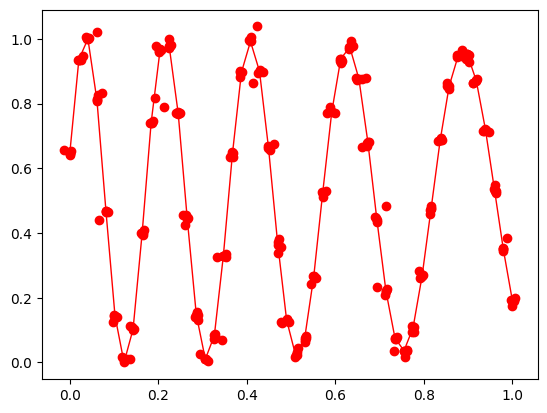

In [7]:
# plot of the new dataset
plt.plot(reaction_HF_test[:,0], U_HF_test, "ro", linewidth=1, label="HF model with noise")
plt.plot(reaction_HF_test_original[:,0], U_HF_test_original, "r-", linewidth=1, label="HF model")
plt.show()

In [8]:
# Number of data of High and Low Fidelity components of the dataset
n_HF = np.array([100])
Nlf = np.array([200])
n_val_HF = 100
N_val_lf = 200

batch_size=[200,100]


In [9]:
U_LF_list = []
U_HF_list = []
# number of epochs 
Nepo=[7000,8000]

# NepoLF = 7000  # number of epochs for first NN: NN_LF
# NepoHF = 8000  # number of epochs for second NN: NN_HF

r2_HF_df = pd.DataFrame(columns=['Discretization','diffusion','R2'])  # dataframe which stores HF R^2
r2_LF_df = pd.DataFrame(columns=['Discretization','diffusion','R2'])  # dataframe which stores LF R^2
mse_HF_df = pd.DataFrame(columns=['Discretization','diffusion','MSE'])  # dataframe which stores HF MSE
mse_LF_df = pd.DataFrame(columns=['Discretization','diffusion','MSE'])  # dataframe which stores LF MSE



## Neural Network
Hyperparameter Optimization

********************  # Nb. nodes = 46  ********************
********************  # Diff: = 75  ********************
********************  # NHF: = 100  ********************
********************  # NLF: = 200  ********************


[I 2024-08-20 10:23:16,076] A new study created in RDB with name: no-name-7e1de09a-04de-4192-af60-c8889a964a22
[I 2024-08-20 10:35:42,063] Trial 4 finished with value: 0.12061102889579327 and parameters: {'nodes': 4, 'l2weight': 0.09263009430167021, 'lr': 0.0001216507590337352, 'kernel_init': 'uniform', 'opt': 'Adamax'}. Best is trial 4 with value: 0.12061102889579327.
[I 2024-08-20 10:35:48,041] Trial 2 finished with value: 0.08592664877950572 and parameters: {'nodes': 33, 'l2weight': 0.002894745015465026, 'lr': 0.013324958785217349, 'kernel_init': 'glorot_uniform', 'opt': 'Adamax'}. Best is trial 2 with value: 0.08592664877950572.
[I 2024-08-20 10:35:48,301] Trial 0 finished with value: 0.11946229791091295 and parameters: {'nodes': 25, 'l2weight': 0.008935351809297358, 'lr': 0.003464032002217678, 'kernel_init': 'uniform', 'opt': 'Adam'}. Best is trial 1 with value: 0.019274640390788675.
[I 2024-08-20 10:35:48,958] Trial 3 finished with value: 0.11318695968293968 and parameters: {'nod

New parameters identified during HPO:
{'kernel_init': 'glorot_uniform',
 'l2weight': 0.03711750915883216,
 'lr': 0.024244197598433916,
 'nodes': 55,
 'opt': 'Adamax'}
The function training took 221.177514 seconds.


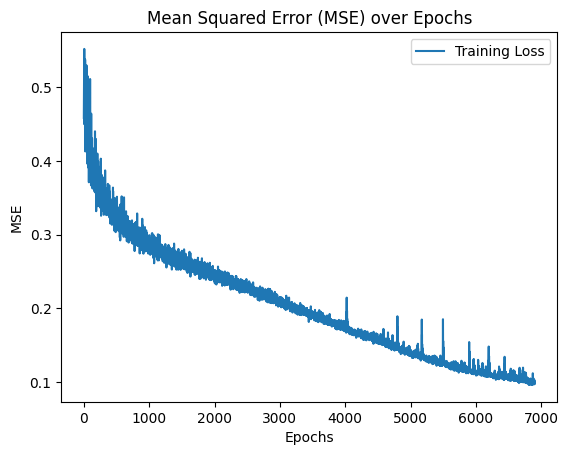

[I 2024-08-20 10:58:07,216] A new study created in RDB with name: no-name-0d3a6db1-f2f2-477a-8804-0a1142f2162d
[I 2024-08-20 11:11:17,670] Trial 3 finished with value: 0.10665266620115675 and parameters: {'nodes': 13, 'l2weight': 0.09793630533283947, 'lr': 0.005460529342616088, 'kernel_init': 'glorot_uniform', 'opt': 'Adam'}. Best is trial 3 with value: 0.10665266620115675.
[I 2024-08-20 11:11:19,469] Trial 1 finished with value: 0.08875782011555008 and parameters: {'nodes': 6, 'l2weight': 0.0038394871490674025, 'lr': 0.0004450435235478617, 'kernel_init': 'uniform', 'opt': 'Adamax'}. Best is trial 1 with value: 0.08875782011555008.
[I 2024-08-20 11:11:20,118] Trial 2 finished with value: 0.15617212643093423 and parameters: {'nodes': 35, 'l2weight': 0.0005700465511682679, 'lr': 0.06944494505222062, 'kernel_init': 'uniform', 'opt': 'Adamax'}. Best is trial 1 with value: 0.08875782011555008.
[I 2024-08-20 11:11:40,220] Trial 7 finished with value: 0.09408461535129542 and parameters: {'nod

New parameters identified during HPO:
{'kernel_init': 'glorot_uniform',
 'l2weight': 0.025443311601261794,
 'lr': 0.0033275229144994574,
 'nodes': 17,
 'opt': 'Adamax'}
The function training took 225.301217 seconds.


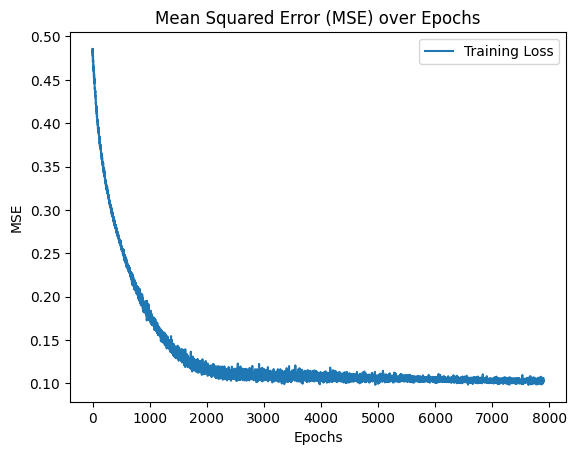

low fidelity NN
Test MSE: 0.08450166636467589
R^2: 0.282596514835454
Final model
Test MSE: 0.09180253129493571
R^2: 0.18901488494805074


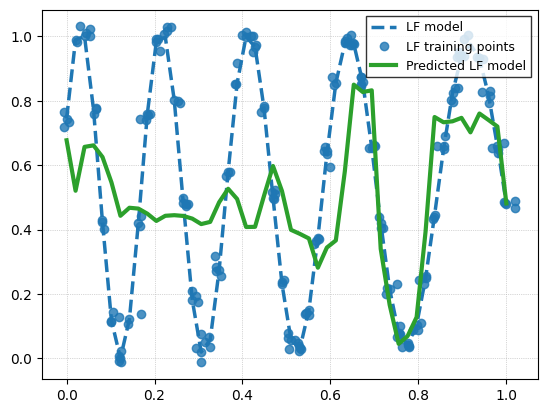

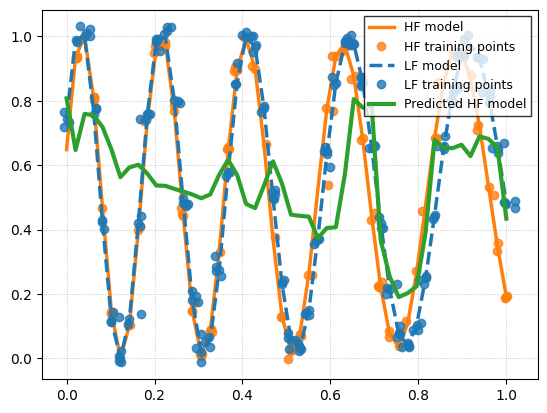

Empty DataFrame
Columns: [Discretization, diffusion, R2]
Index: []
Empty DataFrame
Columns: [Discretization, diffusion, MSE]
Index: []


In [19]:
m=0
d=2       
test_mse_HF_list = []
test_mse_LF_list = []

r2_HF_list = []
r2_LF_list = []


# Loop through parameters
for nhf in n_HF:
    for nlf in Nlf:
        for nper in n_per:

            # Print current configuration
            print(f"******** # Nb. nodes = {Discretizations[m]} ********")
            print(f"******** # Diff: = {diffusion[d]} ********")
            print(f"******** # NHF: = {nhf} ********")
            print(f"******** # Nper: = {nper} ********")
            print(f"******** # NLF: = {nlf} ********")


            # Import Low Fidelity data
            file_path_LF = f"../DATA_reaction/reaction_diffusion_LF_{Discretizations[m]}_d{diffusion[d]}.mat"
            reaction_LF_test, U_LF_test = import_data(file_path_LF)

            # Normalize and select specific data points
            U_LF_test = U_LF_test[:, -1, int(4*(Discretizations[m]-1)/9), int(4*(Discretizations[m]-1)/9)]
            U_LF_test = normalization(U_LF_test)
            reaction_LF_test = normalization(reaction_LF_test)
            
            # Transform Low Fidelity dataset
            reaction_LF_test_original = np.c_[reaction_LF_test, np.abs(np.sin(5 * np.pi * reaction_LF_test[:, 0] - 5 * np.pi / 6))]
            U_LF_test_original = U_LF_test  # Keep original for later use
            
            # Data augmentation with noise
            noise_std1 = [0.02, 0.01, 0.02, 0.01]
            noise_std2 = [0.01, 0.005, 0.01, 0.005]
            U_LF_test, reaction_LF_test = add_noise(noise_std1, noise_std2, reaction_LF_test, U_LF_test)
            
            # Prepare datasets for training and validation
            reaction_LF, U_train_LF = select_random_data(reaction_LF_test, U_LF_test, nlf)
            reaction_HF, U_HF = select_random_data(reaction_HF_test, U_HF_test, nhf)

            # Transform datasets for training
            reaction_LF = augment_with_sin(reaction_LF)
            reaction_LF_test = augment_with_sin(reaction_LF_test)

            # Prepare validation datasets
            reaction_HF_val, U_HF_val = select_random_data(reaction_HF_test, U_HF_test, nhf)
            reaction_LF_val, U_train_LF_val = select_random_data(reaction_LF_test, U_LF_test, nlf)

            # Transform validation dataset
            reaction_LF_val = augment_with_sin(reaction_LF_val)


            ########################## Neural Network ##########################
            K.clear_session()

            # Define and train the Multifidelity network
            model_definition = {
                "network_type": "2step",
                "names": ["LF", "Hfper", "HF"],
                "data_train": [reaction_LF, reaction_HF],
                "output_train": [U_train_LF, U_HF],
                "data_val": [reaction_LF_val, reaction_HF_val],
                "output_val": [U_train_LF_val, U_HF_val],
                "N": Nepo,
                "n": batch_size,
                "train": True,
                "do_HPO": True,
                "verbose": False
            }
            model = NetworkFactory.build_network(**model_definition)


# Print final results
print(r2_HF_df.round(5))
print(mse_HF_df.round(5))


# for nhf in n_HF:
#     for nlf in Nlf:

#         print(
#         f"********************  # Nb. nodes = {Discretizations[m]}  ********************"
#         )
        
#         print(
#         f"********************  # Diff: = {diffusion[d]}  ********************"
#         )
        
#         print(
#         f"********************  # NHF: = {nhf}  ********************"
#         )
#         print(
#         f"********************  # NLF: = {nlf}  ********************"
#         )
#         ### import of the Low Fidelity component of the dataset 
#         file_path_LF = "../DATA_reaction_diffusion_test_case/reaction_diffusion_LF_"+str(Discretizations[m])+"_d"+str(diffusion[d])+".mat"
#         (reaction_LF_test, U_LF_test) = import_data(file_path_LF)

#         # selection and normalization of the dataset
#         U_LF_test = U_LF_test[:,- 1,int(4*(Discretizations[m]-1)/9),int(4*(Discretizations[m]-1)/9)] # indexes to find the same temporal (last) and spatial points        
#         U_LF_test = normalization(U_LF_test)
#         reaction_LF_test = normalization(reaction_LF_test)
        
#         # transformation of the Low fidelity test set
#         reaction_LF_test_original=np.c_[reaction_LF_test, np.abs(np.sin(5*np.pi*reaction_LF_test[:, 0]-5*np.pi/6))]
#         U_LF_test_original=U_LF_test # keep the original for later evaluation and representation 
        
#         # dataset augmentation adding a noise
#         noise_std1=[0.02,0.01,0.02,0.01]
#         noise_std2=[0.01,0.005,0.01,0.005]
#         (U_LF_test,reaction_LF_test)=add_noise(noise_std1,noise_std2,reaction_LF_test,U_LF_test.reshape(-1,1))
        
#         # randomization and selection of the training set
#         permutation = np.random.permutation(len(reaction_HF_test))
#         reaction_HF = reaction_HF_test[permutation,:][0:nhf,:]
#         U_HF = U_HF_test[permutation][0:nhf]

#         permutation = np.random.permutation(len(reaction_LF_test))
#         reaction_LF = reaction_LF_test[permutation][0:nlf]
#         U_train_LF = U_LF_test[permutation][0:nlf]

#         # transformation of the dataset
#         reaction_LF=np.c_[reaction_LF, np.abs(np.sin(5*np.pi*reaction_LF[:, 0]-5*np.pi/6))]
#         reaction_LF_test=np.c_[reaction_LF_test, np.abs(np.sin(5*np.pi*reaction_LF_test[:, 0]-5*np.pi/6))]
        

#         # validation set
#         permutation_val = np.random.permutation(len(reaction_HF_test))
#         reaction_HF_val = reaction_HF_test[permutation_val,:][0:n_val_HF,:]
#         U_HF_val = U_HF_test[permutation_val][0:n_val_HF]

#         permutation_val = np.random.permutation(len(reaction_LF_test))
#         reaction_LF_val = reaction_LF_test[permutation_val][0:N_val_lf]
#         U_train_LF_val = U_LF_test[permutation_val][0:N_val_lf]

#         # transformation of the dataset
#         reaction_LF_val=np.c_[reaction_LF_val, np.abs(np.sin(5*np.pi*reaction_LF_val[:, 0]-5*np.pi/6))]




#         ##########################      Neural Network     ##########################
#         K.clear_session()
        



#         # Multifidelity network 
#         names=["LF","HF"]
#         data_train=[reaction_LF, reaction_HF]
#         output_train=[U_train_LF,U_HF]
#         data_val=[reaction_LF_val, reaction_HF_val]
#         output_val=[U_train_LF_val,U_HF_val]

#         definition_2steps = {
#                             "network_type": "2step",
#                             "names": names,
#                             "data_train": data_train,
#                             "output_train": output_train,
#                             "data_val": data_val,
#                             "output_val": output_val,
#                             "N": Nepo,
#                             "n": batch_size,
#                             "train": True,
#                             "do_HPO": True,
#                             "verbose": False
#                             }
        
#         model= NetworkFactory.build_network(**definition_2steps)



#         ULF = model.model_list[0].prediction(reaction_LF_test_original)
#         print("low fidelity NN")
        
#         (test_mse_LF,r2_LF) = model.model_list[0].performance(reaction_LF_test_original,U_LF_test_original)
#         test_mse_LF_list.append(test_mse_LF)
#         r2_LF_list.append(r2_LF)

#         input_HF = np.concatenate(
#             (reaction_HF_test_original,  model.model_list[0].prediction(reaction_HF_test_original).reshape(-1,1)),axis=1
#         )  # <- TRAINING INPUT for the second NN: NN_HF

#         input_HF_train = np.concatenate(
#             (reaction_HF,  model.model_list[0].prediction(reaction_HF).reshape(-1,1)),axis=1
#         ) 
#         print("Final model")
#         (test_mse_HF,r2_HF) = model.model_list[1].performance(input_HF,U_HF_test_original)                
#         test_mse_HF_list.append(test_mse_HF)
#         r2_HF_list.append(r2_HF)
        
        
#         # plots of the model

#         plt.figure()

#         plt.plot(reaction_LF_test_original[:, 0], U_LF_test_original, color="#1F77B4", linestyle="--", linewidth=2.5, label="LF model")

#         plt.plot(
#             reaction_LF[:, 0],
#             U_train_LF,
#             "o",
#             markersize=6,
#             color="#1F77B4",
#             alpha=0.8,
#             label="LF training points",
#         )

#         plt.plot(
#             reaction_LF_test_original[:, 0],
#             model.model_list[0].prediction(reaction_LF_test_original),
#             color="#2CA02C",
#             linestyle="-",
#             linewidth=3,
#             label="Predicted LF model",
#         )

#         plt.legend(prop={"size": 9}, loc="best", frameon=True, fancybox=False, shadow=False, facecolor="white", edgecolor="black")
#         plt.grid(True, which='both', linestyle=':', linewidth=0.5)

#         plt.show()
        


#         plt.figure()

#         plt.plot(reaction_HF_test_original[:,0], U_HF_test_original, color="#FF7F0E", linestyle="-", linewidth=2.5, label="HF model")

#         plt.plot(
#             input_HF_train[:, 0],
#             U_HF,
#             "o",
#             markersize=6,
#             color="#FF7F0E",
#             alpha=0.8,
#             label="HF training points",
#         )

#         plt.plot(reaction_LF_test_original[:, 0], U_LF_test_original, color="#1F77B4", linestyle="--", linewidth=2.5, label="LF model")

#         plt.plot(
#             reaction_LF[:,0],
#             U_train_LF,
#             "o",
#             markersize=6,
#             color="#1F77B4",
#             alpha=0.8,
#             label="LF training points",
#         )

#         plt.plot(
#             input_HF[:, 0],
#             model.model_list[1].prediction(input_HF),
#             color="#2CA02C",
#             linestyle="-",
#             linewidth=3,
#             label="Predicted HF model",
#         )

#         plt.legend(prop={"size": 9}, loc="best", frameon=True, fancybox=False, shadow=False, facecolor="white", edgecolor="black")
#         plt.grid(True, which='both', linestyle=':', linewidth=0.5)

#         plt.show()
        
        
# print(r2_HF_df.round(5))
# print(mse_HF_df.round(5))

### Cycle on the Discretization and the value of the diffusion 

Folder '2_step_models' already exists.
********************  # Nb. nodes = 46  ********************
********************  # Diff: = 0  ********************
********************  # NHF: = 100  ********************
********************  # NLF: = 200  ********************
The function training took 162.079597 seconds.


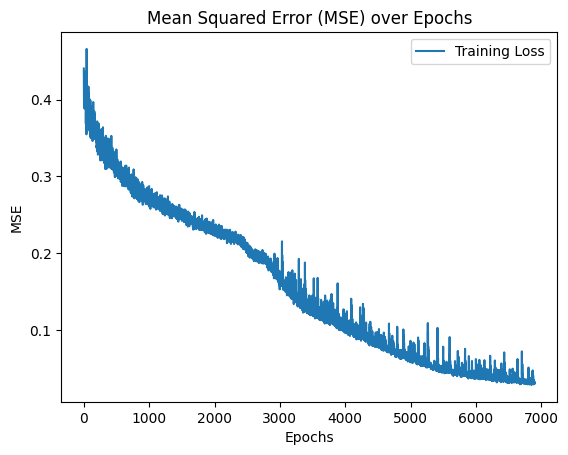

The function training took 175.834762 seconds.


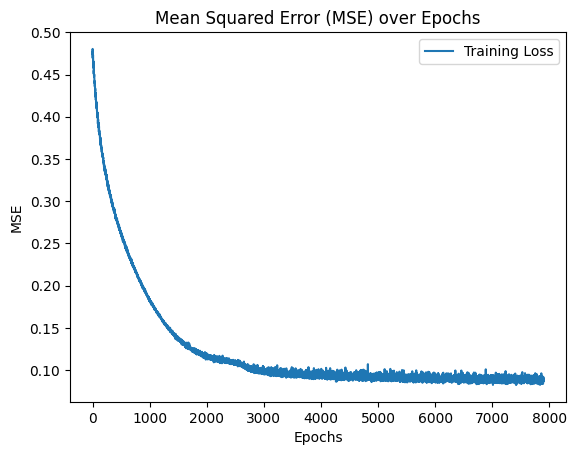

Low fidelity NN
Test MSE: 0.004303182647300618
R^2: 0.9654590824272943
Final model
Test MSE: 0.09364262535920397
R^2: 0.17275946284402732


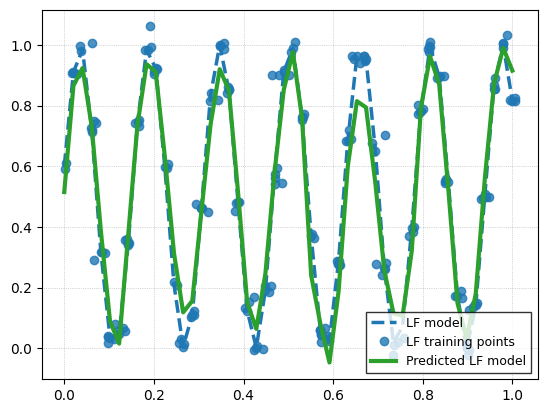

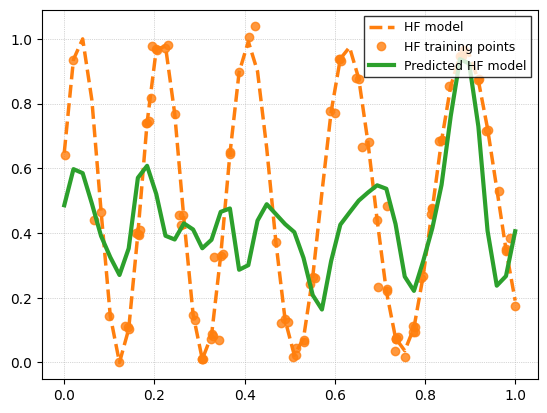

Model saved to c:\Users\Giacomo\Documents\GitHub\pacs_new\PACS_project2\Diffusion\2_step_models\46_model_0.keras
Model saved to c:\Users\Giacomo\Documents\GitHub\pacs_new\PACS_project2\Diffusion\2_step_models\46_model_1.keras
********************  # Nb. nodes = 46  ********************
********************  # Diff: = 5  ********************
********************  # NHF: = 100  ********************
********************  # NLF: = 200  ********************
The function training took 192.771805 seconds.


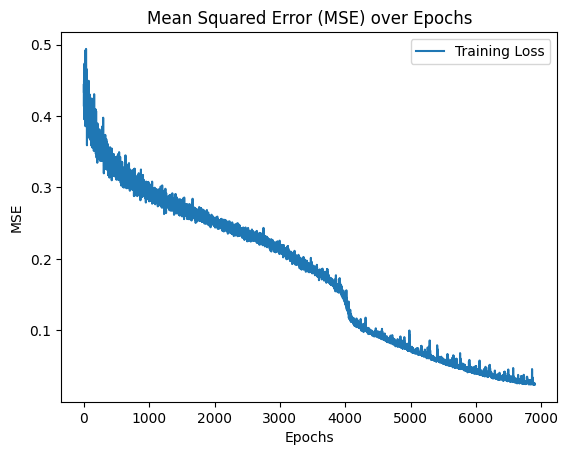

The function training took 209.497076 seconds.


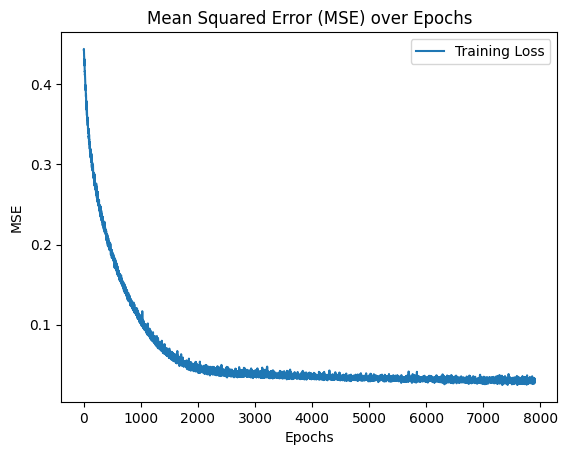

Low fidelity NN
Test MSE: 0.0021691953124425203
R^2: 0.9809320993461061
Final model
Test MSE: 0.019227904419355256
R^2: 0.8301403669617666


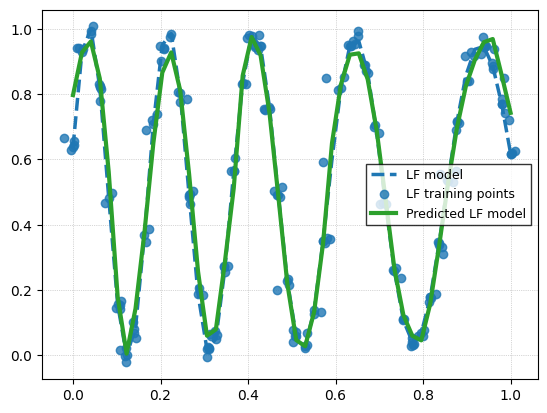

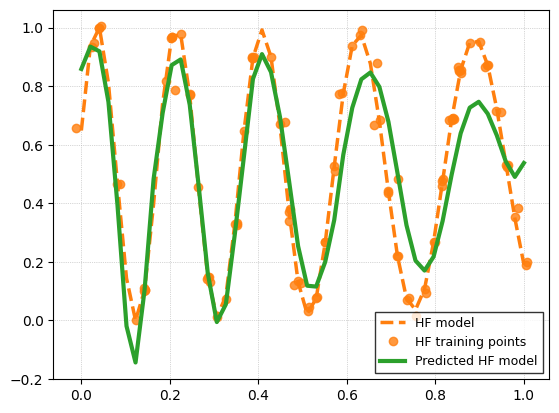

Model saved to c:\Users\Giacomo\Documents\GitHub\pacs_new\PACS_project2\Diffusion\2_step_models\46_model_0.keras
Model saved to c:\Users\Giacomo\Documents\GitHub\pacs_new\PACS_project2\Diffusion\2_step_models\46_model_1.keras
********************  # Nb. nodes = 46  ********************
********************  # Diff: = 75  ********************
********************  # NHF: = 100  ********************
********************  # NLF: = 200  ********************
The function training took 195.176229 seconds.


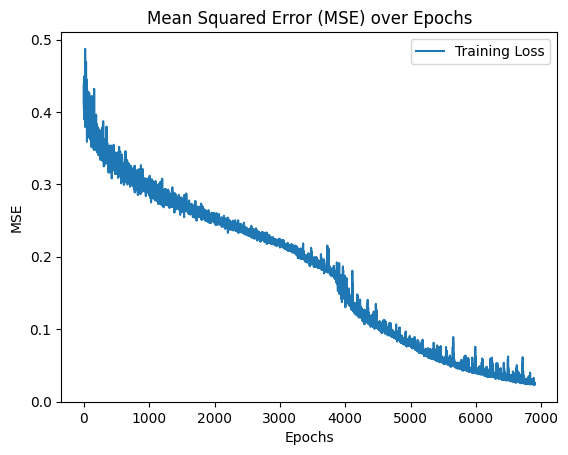

The function training took 229.730359 seconds.


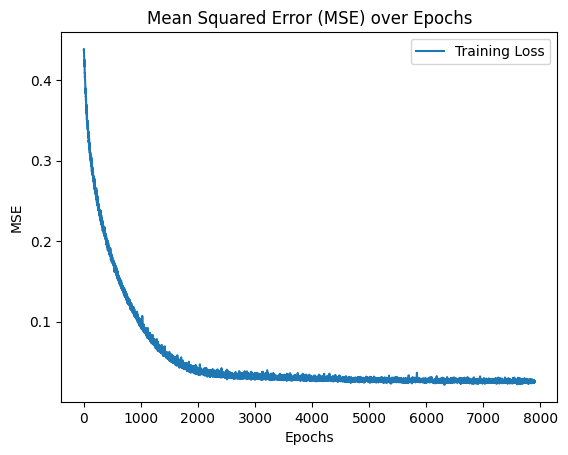

Low fidelity NN
Test MSE: 0.0035577389137464916
R^2: 0.9697954560444715
Final model
Test MSE: 0.01733164962756748
R^2: 0.8468919138831167


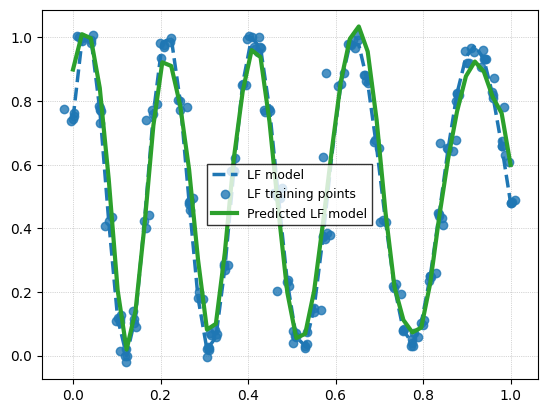

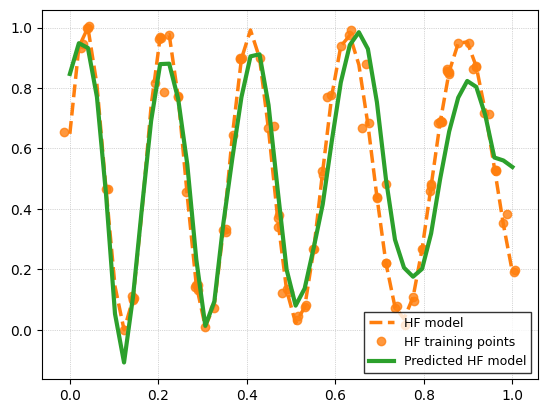

Model saved to c:\Users\Giacomo\Documents\GitHub\pacs_new\PACS_project2\Diffusion\2_step_models\46_model_0.keras
Model saved to c:\Users\Giacomo\Documents\GitHub\pacs_new\PACS_project2\Diffusion\2_step_models\46_model_1.keras
********************  # Nb. nodes = 46  ********************
********************  # Diff: = 1  ********************
********************  # NHF: = 100  ********************
********************  # NLF: = 200  ********************
The function training took 201.602728 seconds.


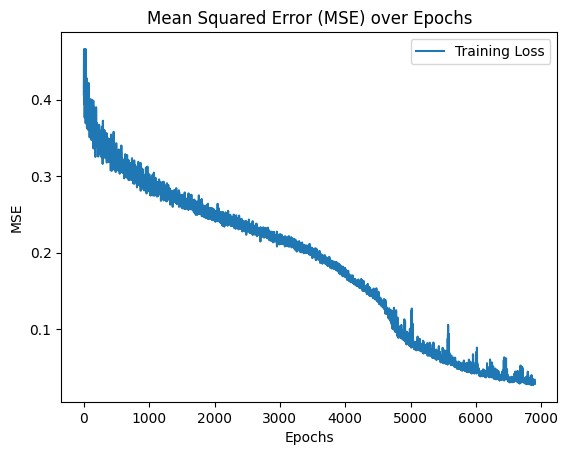

The function training took 223.301648 seconds.


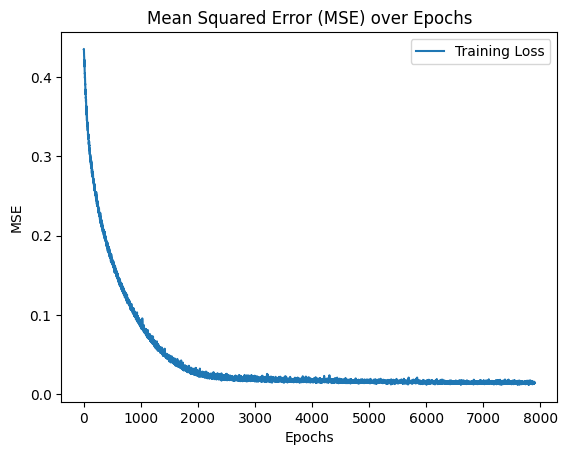

Low fidelity NN
Test MSE: 0.01876615917283958
R^2: 0.8378802796814169
Final model
Test MSE: 0.009475228402196847
R^2: 0.9162956719438191


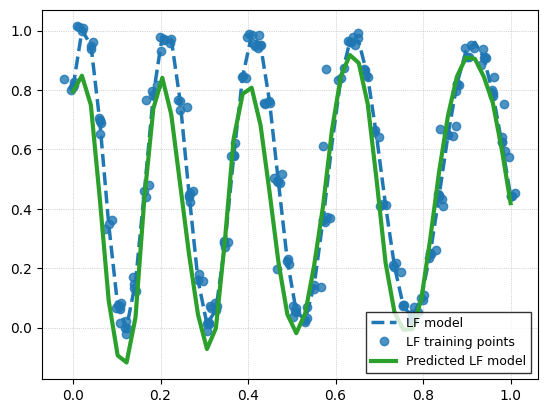

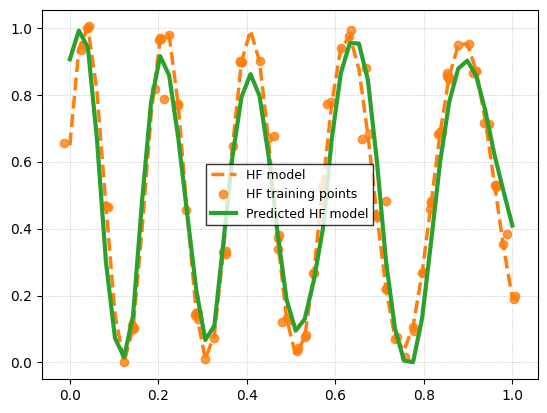

Model saved to c:\Users\Giacomo\Documents\GitHub\pacs_new\PACS_project2\Diffusion\2_step_models\46_model_0.keras
Model saved to c:\Users\Giacomo\Documents\GitHub\pacs_new\PACS_project2\Diffusion\2_step_models\46_model_1.keras
********************  # Nb. nodes = 28  ********************
********************  # Diff: = 0  ********************
********************  # NHF: = 100  ********************
********************  # NLF: = 200  ********************
The function training took 222.695860 seconds.


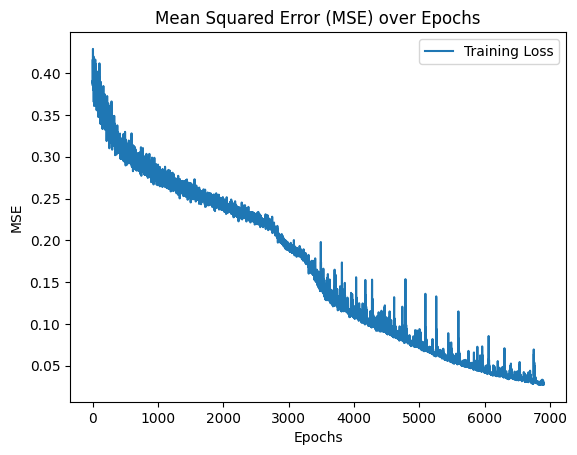

The function training took 266.597841 seconds.


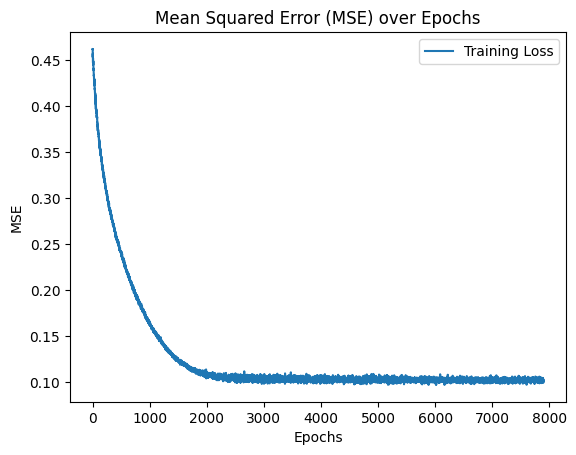

Low fidelity NN
Test MSE: 0.005108720437234646
R^2: 0.9590090429332085
Final model
Test MSE: 0.10685396361370808
R^2: 0.05605027712563426


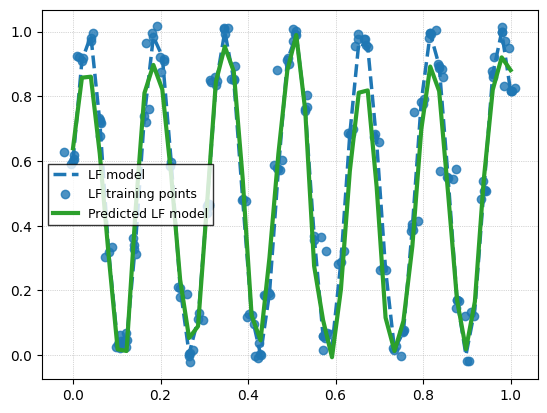

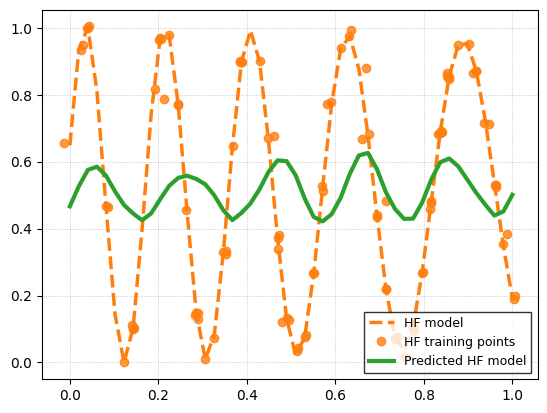

Model saved to c:\Users\Giacomo\Documents\GitHub\pacs_new\PACS_project2\Diffusion\2_step_models\28_model_0.keras
Model saved to c:\Users\Giacomo\Documents\GitHub\pacs_new\PACS_project2\Diffusion\2_step_models\28_model_1.keras
********************  # Nb. nodes = 28  ********************
********************  # Diff: = 5  ********************
********************  # NHF: = 100  ********************
********************  # NLF: = 200  ********************
The function training took 249.501323 seconds.


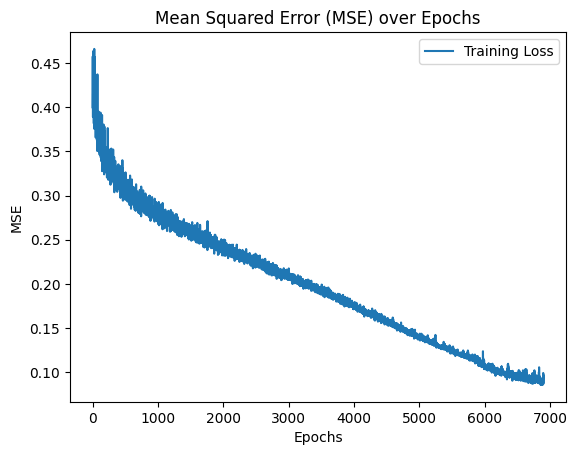

The function training took 258.336172 seconds.


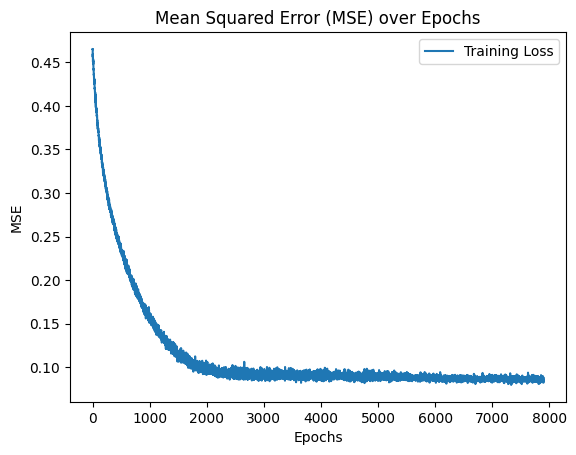

Low fidelity NN
Test MSE: 0.09114278736135357
R^2: 0.19526021854651332
Final model
Test MSE: 0.09037857425965042
R^2: 0.2015941454956689


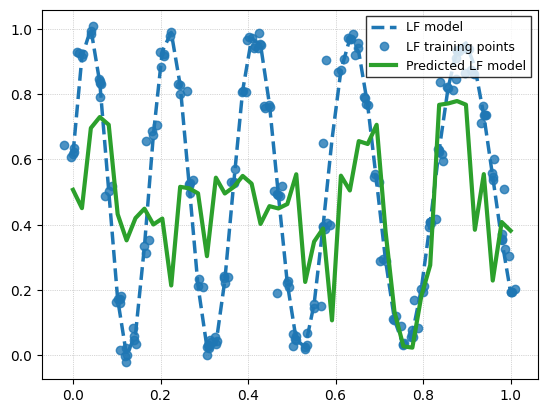

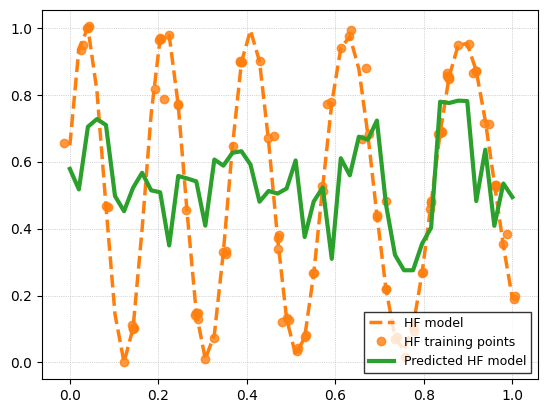

Model saved to c:\Users\Giacomo\Documents\GitHub\pacs_new\PACS_project2\Diffusion\2_step_models\28_model_0.keras
Model saved to c:\Users\Giacomo\Documents\GitHub\pacs_new\PACS_project2\Diffusion\2_step_models\28_model_1.keras
********************  # Nb. nodes = 28  ********************
********************  # Diff: = 75  ********************
********************  # NHF: = 100  ********************
********************  # NLF: = 200  ********************
The function training took 174.720399 seconds.


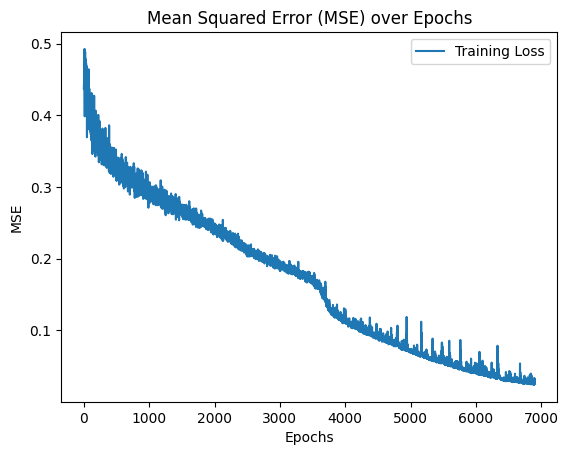

The function training took 194.724304 seconds.


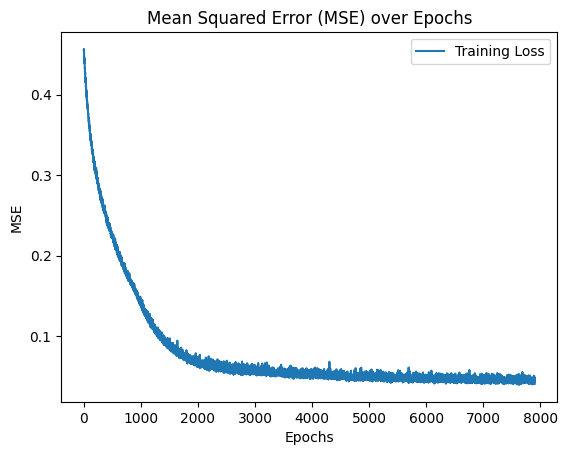

Low fidelity NN
Test MSE: 0.0022431902709568944
R^2: 0.9809214693495907
Final model
Test MSE: 0.0387876137683459
R^2: 0.6573495635599336


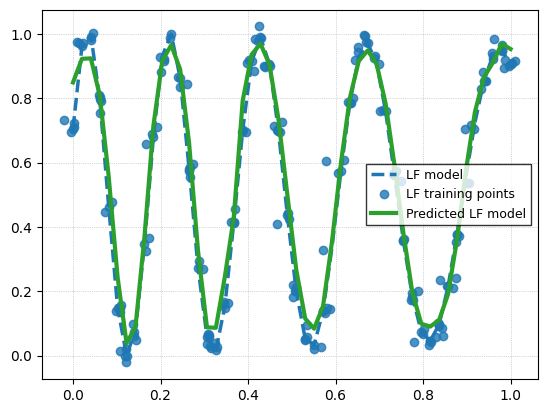

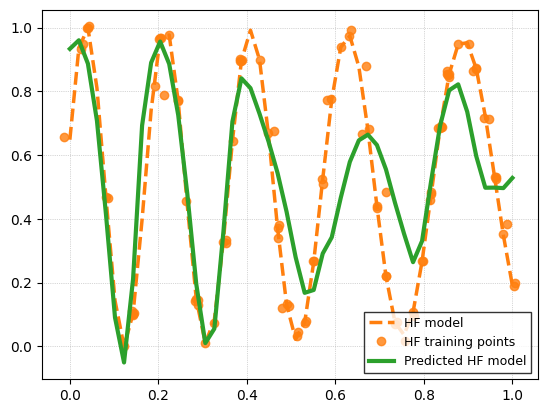

Model saved to c:\Users\Giacomo\Documents\GitHub\pacs_new\PACS_project2\Diffusion\2_step_models\28_model_0.keras
Model saved to c:\Users\Giacomo\Documents\GitHub\pacs_new\PACS_project2\Diffusion\2_step_models\28_model_1.keras
********************  # Nb. nodes = 28  ********************
********************  # Diff: = 1  ********************
********************  # NHF: = 100  ********************
********************  # NLF: = 200  ********************
The function training took 223.858866 seconds.


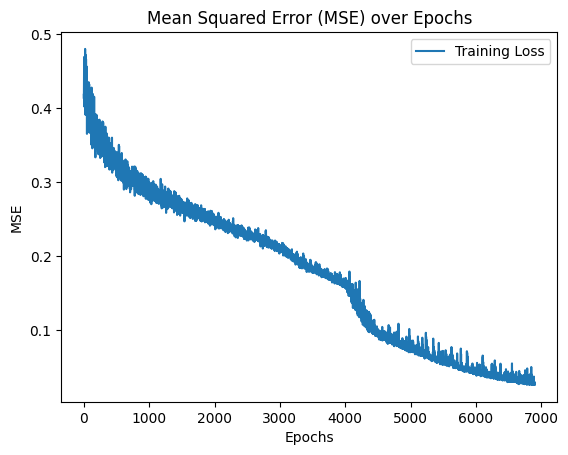

The function training took 220.377391 seconds.


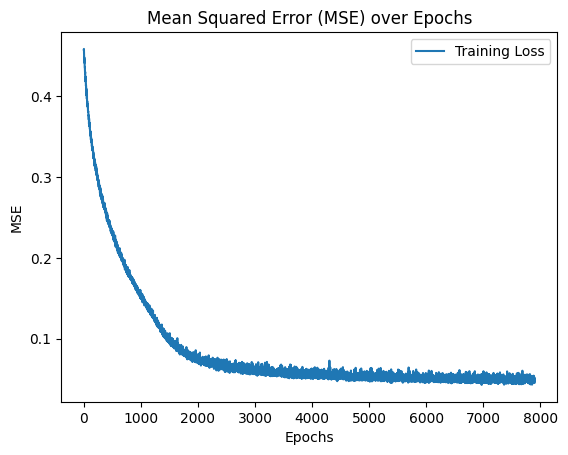

Low fidelity NN
Test MSE: 0.005192255351563938
R^2: 0.9560894285916647
Final model
Test MSE: 0.04530924801081805
R^2: 0.5997373362950218


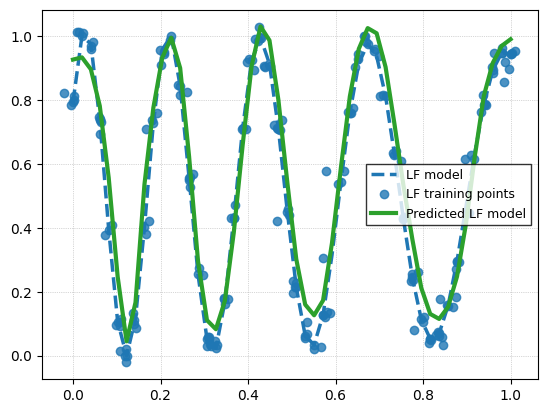

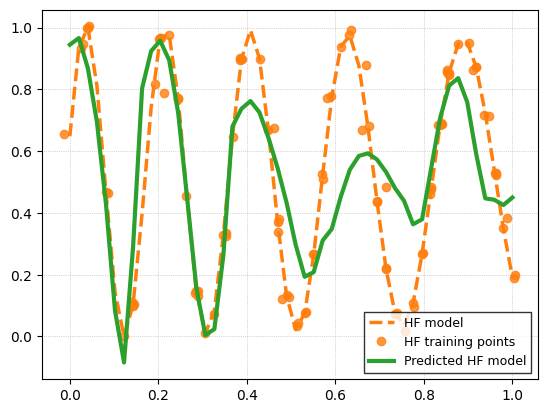

********************  # Nb. nodes = 10  ********************
********************  # Diff: = 0  ********************
********************  # NHF: = 100  ********************
********************  # NLF: = 200  ********************
The function training took 192.433672 seconds.


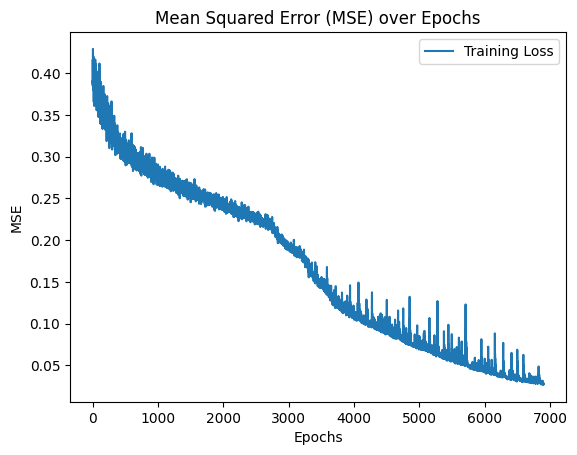

The function training took 210.191768 seconds.


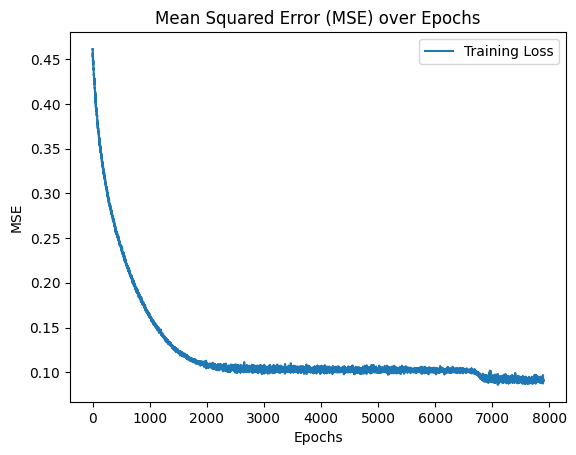

Low fidelity NN
Test MSE: 0.004418222973674927
R^2: 0.964560960800065
Final model
Test MSE: 0.09389217241268899
R^2: 0.17055495995040615


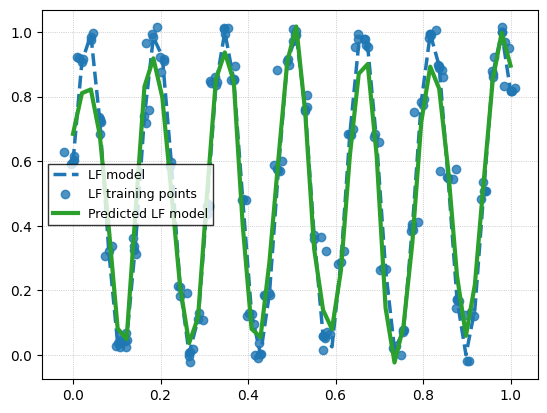

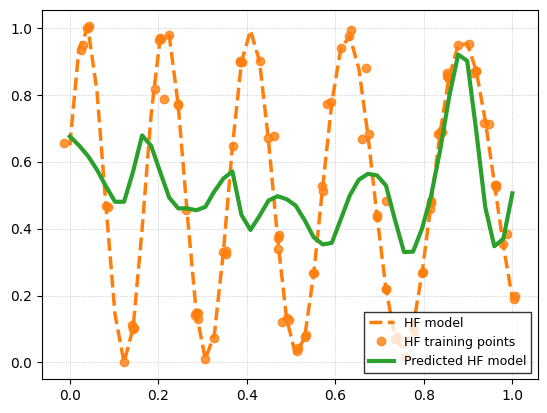

Model saved to c:\Users\Giacomo\Documents\GitHub\pacs_new\PACS_project2\Diffusion\2_step_models\10_model_0.keras
Model saved to c:\Users\Giacomo\Documents\GitHub\pacs_new\PACS_project2\Diffusion\2_step_models\10_model_1.keras
********************  # Nb. nodes = 10  ********************
********************  # Diff: = 5  ********************
********************  # NHF: = 100  ********************
********************  # NLF: = 200  ********************
The function training took 154.045394 seconds.


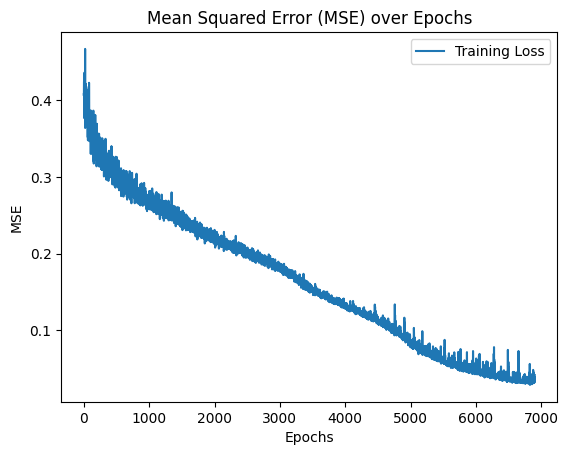

The function training took 172.296147 seconds.


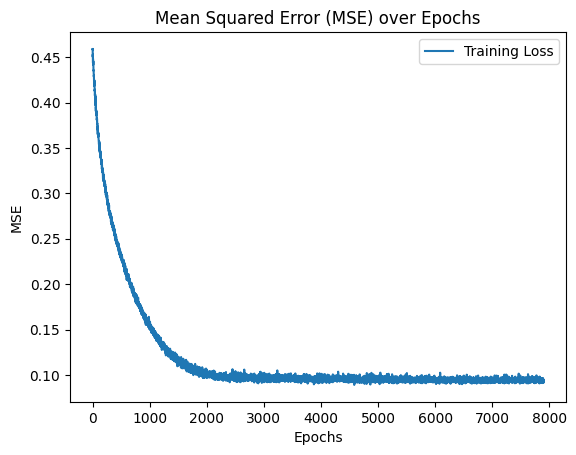

Low fidelity NN
Test MSE: 0.019085284104047435
R^2: 0.8465955749639988
Final model
Test MSE: 0.10286931964761056
R^2: 0.09125068935506164


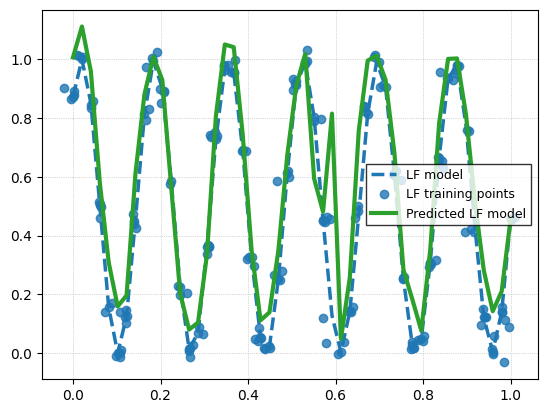

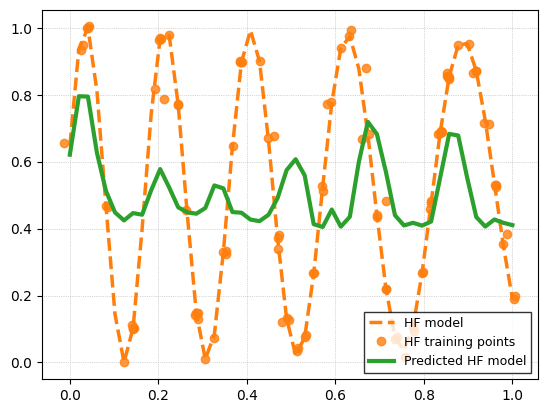

********************  # Nb. nodes = 10  ********************
********************  # Diff: = 75  ********************
********************  # NHF: = 100  ********************
********************  # NLF: = 200  ********************
The function training took 156.080775 seconds.


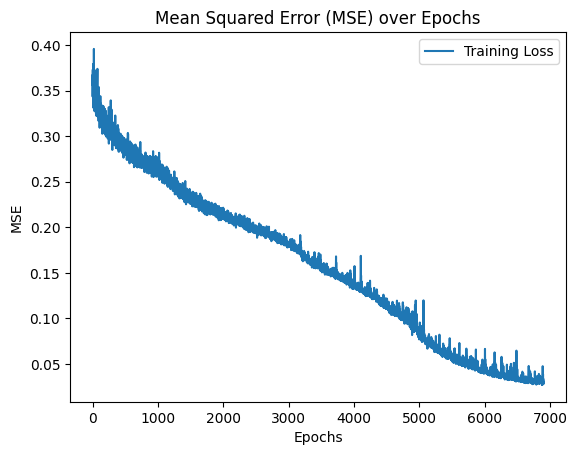

The function training took 161.344650 seconds.


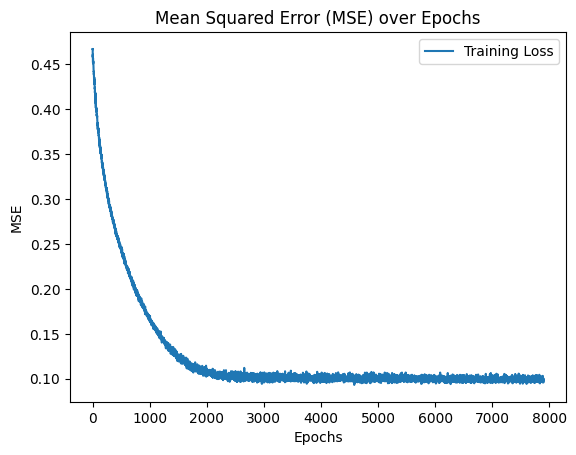

Low fidelity NN
Test MSE: 0.006719400801828621
R^2: 0.9473292861123314
Final model
Test MSE: 0.10467515476733392
R^2: 0.07529791134691877


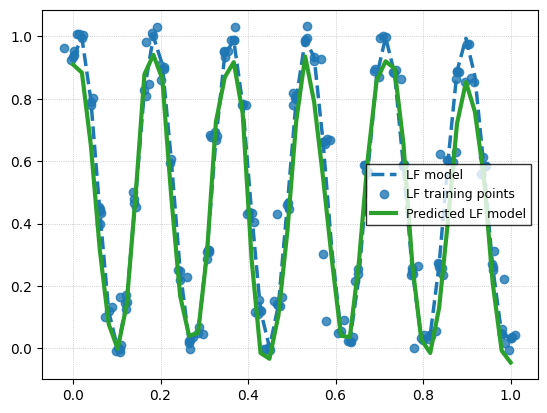

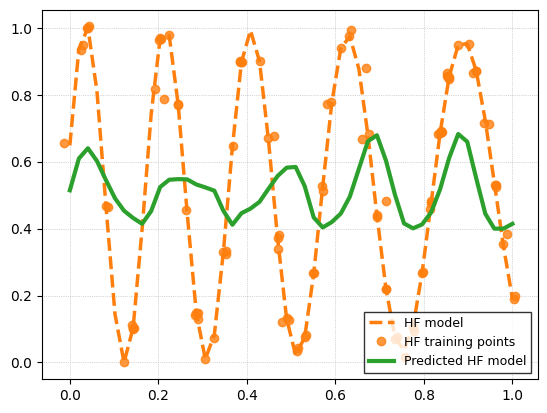

********************  # Nb. nodes = 10  ********************
********************  # Diff: = 1  ********************
********************  # NHF: = 100  ********************
********************  # NLF: = 200  ********************
The function training took 154.612704 seconds.


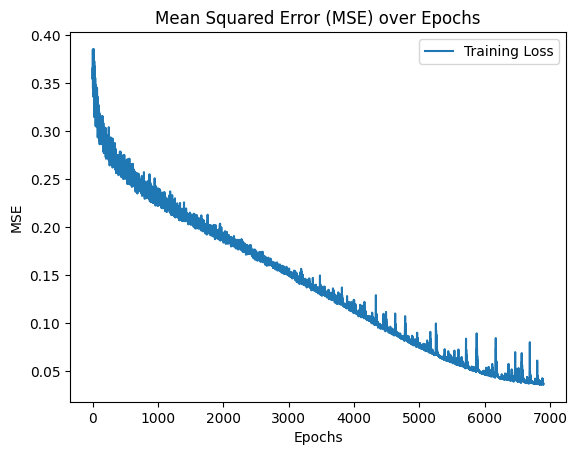

The function training took 166.044490 seconds.


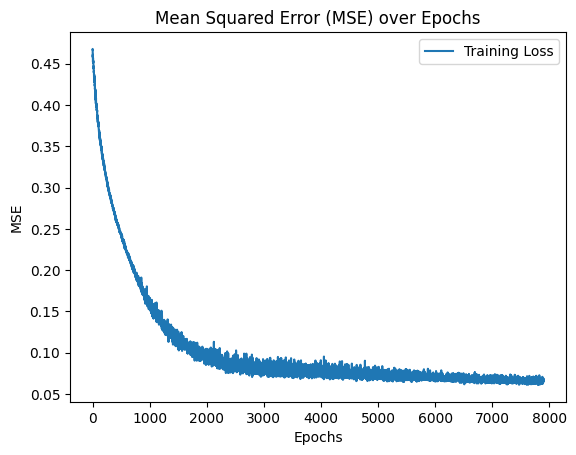

Low fidelity NN
Test MSE: 0.020585451630553416
R^2: 0.8305632307567293
Final model
Test MSE: 0.07216018201568919
R^2: 0.3625357308922962


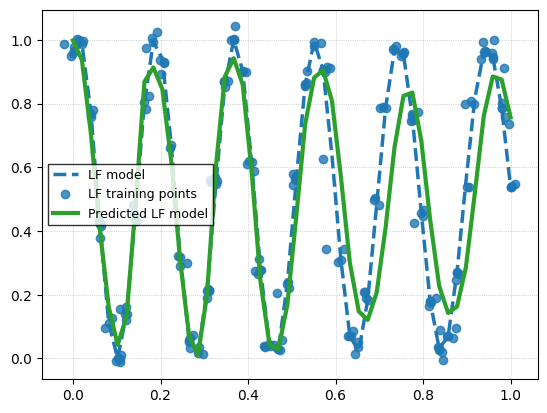

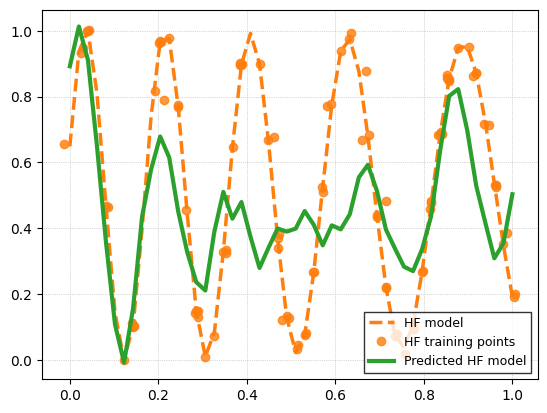

Model saved to c:\Users\Giacomo\Documents\GitHub\pacs_new\PACS_project2\Diffusion\2_step_models\10_model_0.keras
Model saved to c:\Users\Giacomo\Documents\GitHub\pacs_new\PACS_project2\Diffusion\2_step_models\10_model_1.keras
Empty DataFrame
Columns: [Discretization, diffusion, R2]
Index: []
Empty DataFrame
Columns: [Discretization, diffusion, MSE]
Index: []


In [10]:
# Reproducibility settings
seed = 42
np.random.seed(seed)
keras.utils.set_random_seed(seed)
tf.random.set_seed(seed)


# Create the folder for saving models
folder_name = "2_step_models"
folder_path = os.path.join(os.getcwd(), folder_name)
os.makedirs(folder_path, exist_ok=True)
print(f"Folder '{folder_name}' created." if not os.path.exists(folder_path) else f"Folder '{folder_name}' already exists.")


# Main loop
for m, discretization in enumerate(Discretizations):
    test_mse_HF_list, test_mse_LF_list = [], []
    r2_HF_list, r2_LF_list = [], []

    for d, diff in enumerate(diffusion):
        for nhf in n_HF:
            for nlf in Nlf:

                print(f"********************  # Nb. nodes = {discretization}  ********************")
                print(f"********************  # Diff: = {diff}  ********************")
                print(f"********************  # NHF: = {nhf}  ********************")
                print(f"********************  # NLF: = {nlf}  ********************")

                # Import and prepare data
                file_path_LF = f"../DATA_reaction_diffusion_test_case/reaction_diffusion_LF_{discretization}_d{diff}.mat"
                reaction_LF_test, U_LF_test = import_data(file_path_LF)

                # Normalize data
                U_LF_test = U_LF_test[:, -1, int(4 * (discretization - 1) / 9), int(4 * (discretization - 1) / 9)]
                U_LF_test = normalization(U_LF_test)
                reaction_LF_test = normalization(reaction_LF_test)

                # Data transformation and augmentation
                reaction_LF_test_original = augment_with_sin(reaction_LF_test)
                U_LF_test_original = U_LF_test  # Keep original for later evaluation
                noise_std1, noise_std2 = [0.02, 0.01, 0.02, 0.01], [0.01, 0.005, 0.01, 0.005]
                U_LF_test, reaction_LF_test = add_noise(noise_std1, noise_std2, reaction_LF_test, U_LF_test.reshape(-1, 1))

                # Randomization and selection of training set
                reaction_HF, U_HF = select_random_data(reaction_HF_test, U_HF_test, nhf)
                reaction_LF, U_train_LF = select_random_data(reaction_LF_test, U_LF_test, nlf)

                # Further transformation
                reaction_LF = augment_with_sin(reaction_LF)
                reaction_LF_test = augment_with_sin(reaction_LF_test)

                ########################## Neural Network ##########################
                K.clear_session()

                # Model parameters
                bestLF_params = {
                    'kernel_init': 'glorot_uniform',
                    'l2weight': 0.03711750915883216,
                    'lr': 0.024244197598433916,
                    'opt': 'Adamax'
                }

                best_params = {
                    'kernel_init': 'glorot_uniform',
                    'l2weight': 0.025443311601261794,
                    'lr': 0.0033275229144994574,
                    'nodes': 17,
                    'opt': 'Adamax'
                }

                # Build and train the model
                definition_2steps = {
                    "network_type": "2step",
                    "names": ["LF", "HF"],
                    "params": [bestLF_params, best_params],
                    "data_train": [reaction_LF, reaction_HF],
                    "data_val": [reaction_LF, reaction_HF],
                    "output_val": [U_train_LF, U_HF],
                    "output_train": [U_train_LF, U_HF],
                    "N": Nepo,
                    "n": batch_size,
                    "train": True,
                    "do_HPO": False,
                    "verbose": False
                }
                model = NetworkFactory.build_network(**definition_2steps)

                # Low fidelity predictions and evaluation
                ULF = model.model_list[0].prediction(reaction_LF_test_original)
                print("Low fidelity NN")
                test_mse_LF, r2_LF = model.model_list[0].performance(reaction_LF_test_original, U_LF_test_original)
                test_mse_LF_list.append(test_mse_LF)
                r2_LF_list.append(r2_LF)

                # High fidelity input preparation and evaluation
                input_HF = np.concatenate((reaction_HF_test_original, model.model_list[0].prediction(reaction_HF_test_original).reshape(-1, 1)), axis=1)
                input_HF_train = np.concatenate((reaction_HF, model.model_list[0].prediction(reaction_HF).reshape(-1, 1)), axis=1)
                print("Final model")
                test_mse_HF, r2_HF = model.model_list[1].performance(input_HF, U_HF_test_original)
                test_mse_HF_list.append(test_mse_HF)
                r2_HF_list.append(r2_HF)

                # Plotting results
                plot_results(reaction_LF_test_original,U_LF_test_original, ULF, "LF",  reaction_LF, U_train_LF, "#1F77B4", "#2CA02C", "LF model", "Predicted LF model")
                plot_results(reaction_HF_test_original,U_HF_test_original, model.model_list[1].prediction(input_HF), "HF", reaction_HF,  U_HF,"#FF7F0E", "#2CA02C", "HF model", "Predicted HF model")

                # Save the model if it improves on the previous best R2 score
                if not r2_HF_list[:-1] or (r2_HF_list[:-1] and r2_HF > max(r2_HF_list[:-1])):
                    # Create a list of file paths for each model in model_list
                    file_paths = [os.path.join(folder_path, f"{str(discretization)}_model_{i}.keras") for i in range(len(model.model_list))]
                    model.save(file_paths)

# Assuming r2_HF_df and mse_HF_df are defined somewhere in your code
print(r2_HF_df.round(5))
print(mse_HF_df.round(5))

## Save the output

In [12]:
def save_performance(base_dir, r2_HF_df, mse_HF_df, r2_LF_df, mse_LF_df, U_HF_list, U_LF_list):
    # Create the directory if it doesn't exist
    os.makedirs(base_dir, exist_ok=True)

    # File paths
    r2_HF_path = os.path.join(base_dir, "r2_HF_lhs.txt")
    mse_HF_path = os.path.join(base_dir, "mse_HF_lhs.txt")
    r2_LF_path = os.path.join(base_dir, "r2_LF_lhs.txt")
    mse_LF_path = os.path.join(base_dir, "mse_LF_lhs.txt")
    U_HF_list_path = os.path.join(base_dir, "U_HF_list.data")
    U_LF_list_path = os.path.join(base_dir, "U_LF_list.data")

    # Save dataframes to files
    r2_HF_df.to_csv(r2_HF_path, header=True, index=False, sep="\t", mode="a")
    mse_HF_df.to_csv(mse_HF_path, header=True, index=False, sep="\t", mode="a")
    r2_LF_df.to_csv(r2_LF_path, header=True, index=False, sep="\t", mode="a")
    mse_LF_df.to_csv(mse_LF_path, header=True, index=False, sep="\t", mode="a")

    # Save lists to binary files
    with open(U_HF_list_path, "wb") as hf_file:
        pickle.dump(U_HF_list, hf_file)

    with open(U_LF_list_path, "wb") as lf_file:
        pickle.dump(U_LF_list, lf_file)

In [ ]:
def save_performance(base_dir, r2_HF_df, mse_HF_df, r2_LF_df, mse_LF_df, U_HF_list, U_LF_list):
    # Save High-Frequency data
    save_single_performance(base_dir, r2_HF_df, mse_HF_df, U_HF_list, 
                            "r2_HF_lhs.txt", "mse_HF_lhs.txt", "U_HF_list.data")

    # Save Low-Frequency data
    save_single_performance(base_dir, r2_LF_df, mse_LF_df, U_LF_list, 
                            "r2_LF_lhs.txt", "mse_LF_lhs.txt", "U_LF_list.data")
    
def save_single_performance(base_dir, r2_df, mse_df, list_data, r2_filename, mse_filename, list_filename):
    # Create the directory if it doesn't exist
    os.makedirs(base_dir, exist_ok=True)

    # File paths
    r2_path = os.path.join(base_dir, r2_filename)
    mse_path = os.path.join(base_dir, mse_filename)
    list_path = os.path.join(base_dir, list_filename)

    # Save dataframes to files
    r2_df.to_csv(r2_path, header=True, index=False, sep="\t", mode="a")
    mse_df.to_csv(mse_path, header=True, index=False, sep="\t", mode="a")

    # Save list to binary file
    with open(list_path, "wb") as list_file:
        pickle.dump(list_data, list_file)

In [13]:
base_directory = "MF_LF_200_7000_HF_100_8000_2NN_noise_fourier_class"
save_dataframes_and_lists(base_directory, r2_HF_df, mse_HF_df, r2_LF_df, mse_LF_df, U_HF_list, U_LF_list)

OLD

In [ ]:
            # Import Low Fidelity data
            file_path_LF = f"../DATA_reaction_diffusion_test_case/reaction_diffusion_LF_{Discretizations[m]}_d{diffusion[d]}.mat"
            reaction_LF_test, U_LF_test = import_data(file_path_LF)

            # Normalize and select specific data points
            U_LF_test = U_LF_test[:, -1, int(4*(Discretizations[m]-1)/9), int(4*(Discretizations[m]-1)/9)]
            U_LF_test = normalization(U_LF_test)
            reaction_LF_test = normalization(reaction_LF_test)
            
            # Transform Low Fidelity dataset
            reaction_LF_test_original = np.c_[reaction_LF_test, np.abs(np.sin(5 * np.pi * reaction_LF_test[:, 0] - 5 * np.pi / 6))]
            U_LF_test_original = U_LF_test  # Keep original for later use
            
            # Data augmentation with noise
            noise_std1 = [0.02, 0.01, 0.02, 0.01]
            noise_std2 = [0.01, 0.005, 0.01, 0.005]
            U_LF_test, reaction_LF_test = add_noise(noise_std1, noise_std2, reaction_LF_test, U_LF_test.reshape(-1,1))
            
            # Prepare datasets for training and validation
            reaction_LF, U_train_LF = select_random_data(reaction_LF_test, U_LF_test, nlf)
            reaction_per, U_train_per = select_random_data(reaction_HF_test, U_HF_test, nper)
            reaction_HF, U_HF = select_random_data(reaction_HF_test, U_HF_test, nhf)

            # Transform datasets for training
            reaction_LF = augment_with_sin(reaction_LF)
            reaction_LF_test = augment_with_sin(reaction_LF_test)

            # Prepare validation datasets
            reaction_HF_val, U_HF_val = select_random_data(reaction_HF_test, U_HF_test, nhf)
            reaction_per_val, U_per_val = select_random_data(reaction_HF_test, U_HF_test, nper)
            reaction_LF_val, U_train_LF_val = select_random_data(reaction_LF_test, U_LF_test, nlf)

            # Transform validation dataset
            reaction_LF_val = augment_with_sin(reaction_LF_val)

Folder '2_step_models' already exists.
********************  # Nb. nodes = 46  ********************
********************  # Diff: = 0  ********************
********************  # NHF: = 100  ********************
********************  # NLF: = 200  ********************
The function training took 119.441116 seconds.


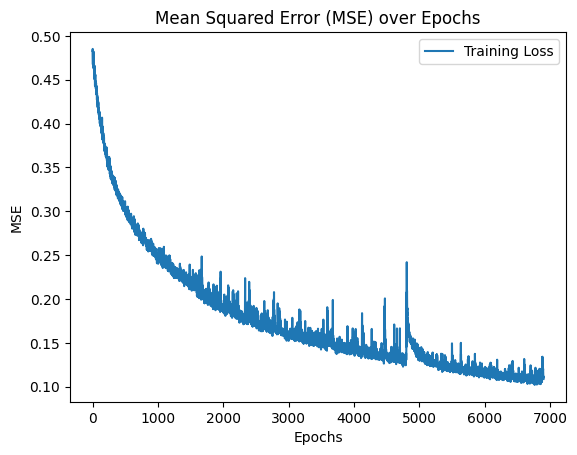

The function training took 136.124575 seconds.


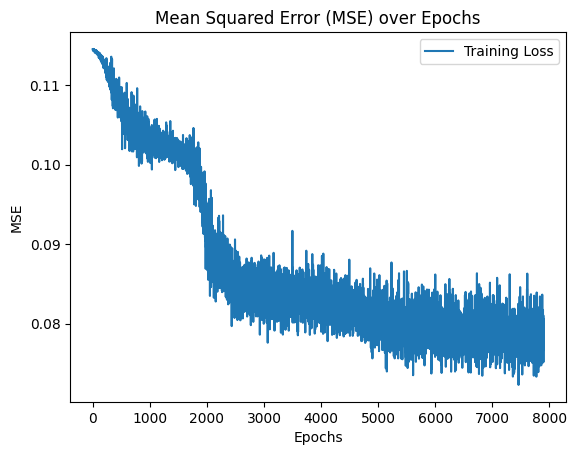

low fidelity NN
Test MSE: 0.028788165470214712
R^2: 0.76892227635286
Final model
Test MSE: 0.08237195418809666
R^2: 0.27232476270539807


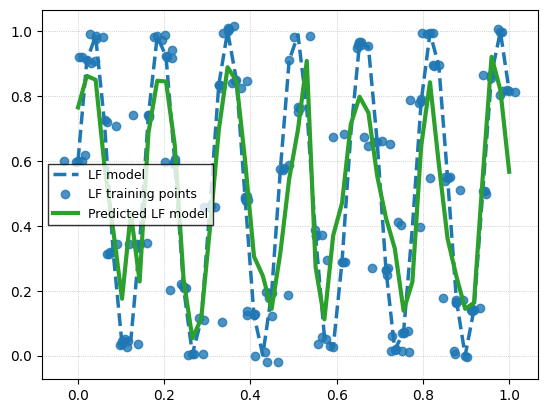

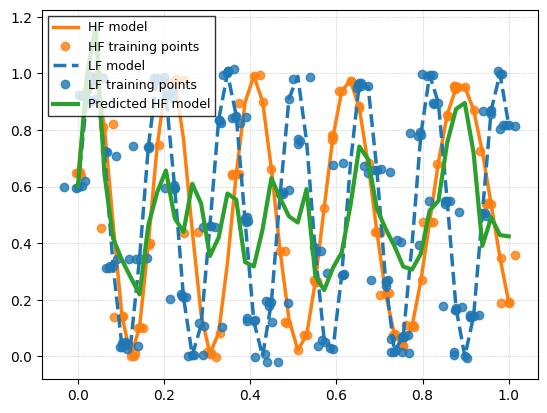

********************  # Nb. nodes = 46  ********************
********************  # Diff: = 5  ********************
********************  # NHF: = 100  ********************
********************  # NLF: = 200  ********************
The function training took 131.845833 seconds.


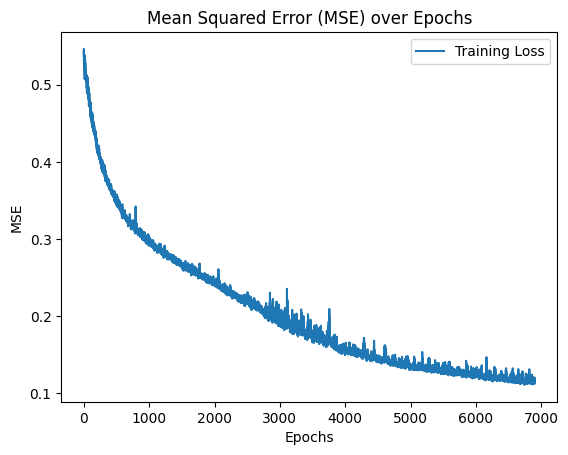

The function training took 145.216224 seconds.


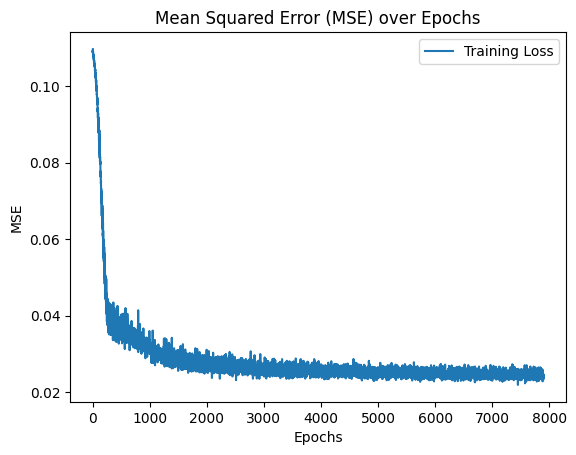

low fidelity NN
Test MSE: 0.008970263271898697
R^2: 0.9211485992401296
Final model
Test MSE: 0.017111899931402982
R^2: 0.8488331864179017


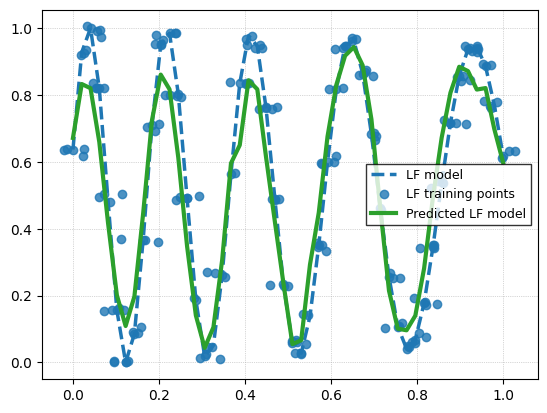

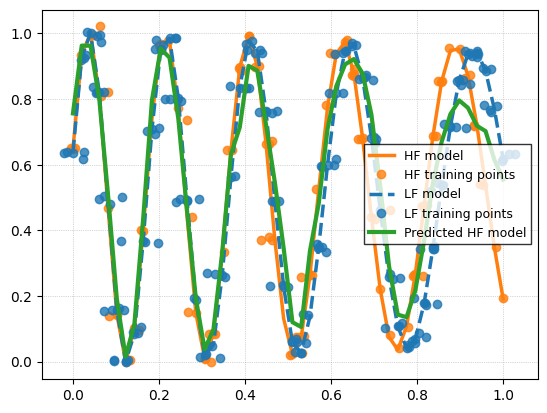

********************  # Nb. nodes = 46  ********************
********************  # Diff: = 75  ********************
********************  # NHF: = 100  ********************
********************  # NLF: = 200  ********************
The function training took 132.895476 seconds.


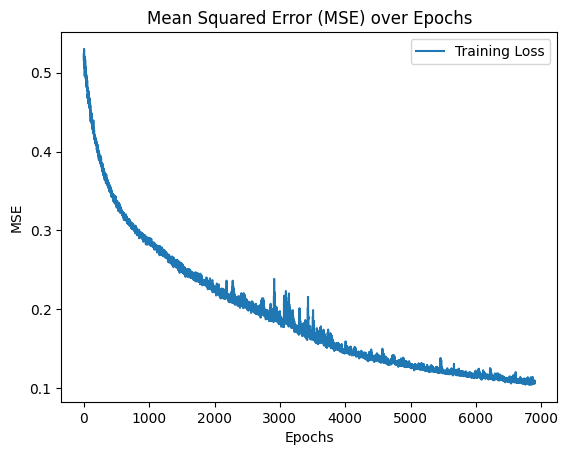

The function training took 143.821080 seconds.


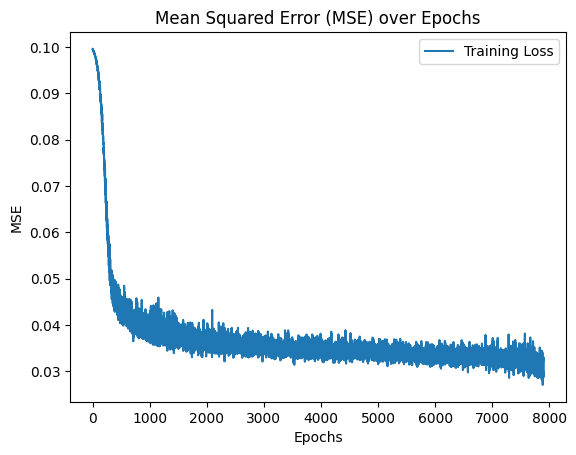

low fidelity NN
Test MSE: 0.0067249916736654815
R^2: 0.9429060671588488
Final model
Test MSE: 0.019699904095960487
R^2: 0.8259707138308918


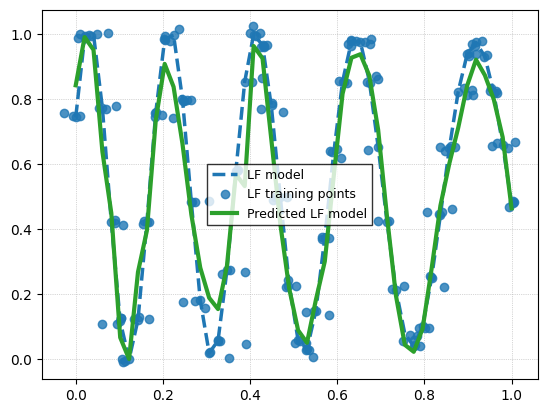

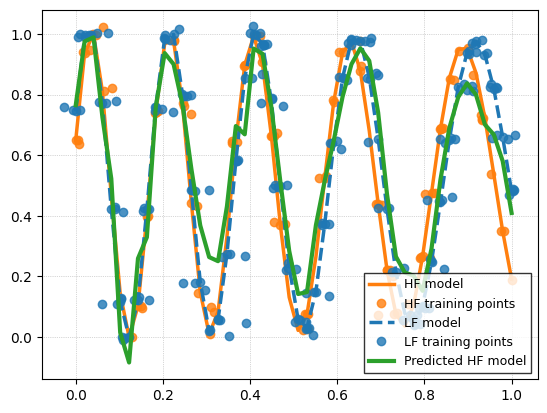

********************  # Nb. nodes = 46  ********************
********************  # Diff: = 1  ********************
********************  # NHF: = 100  ********************
********************  # NLF: = 200  ********************
The function training took 130.881761 seconds.


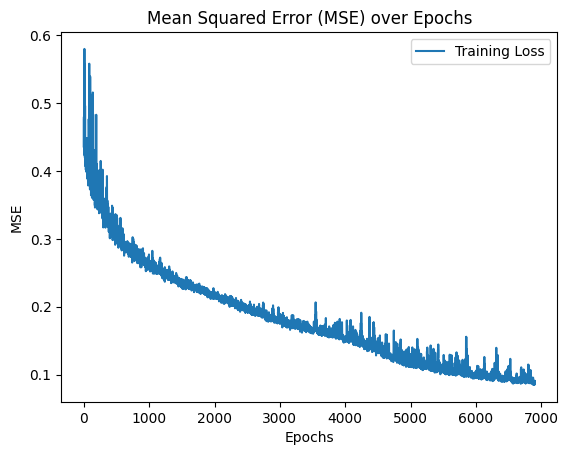

The function training took 144.842151 seconds.


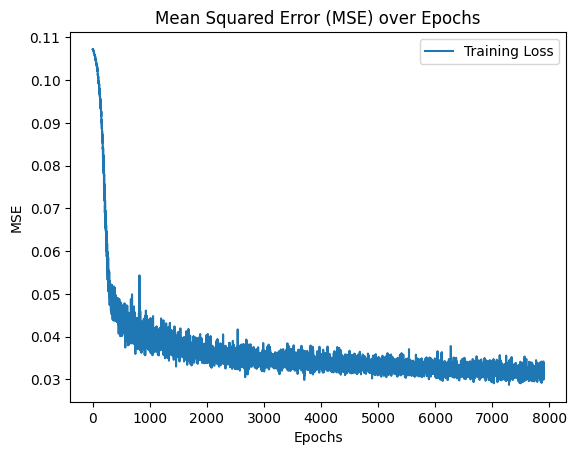

low fidelity NN
Test MSE: 0.0182080840771662
R^2: 0.8427014568649867
Final model
Test MSE: 0.017252140264046815
R^2: 0.8475943009460111


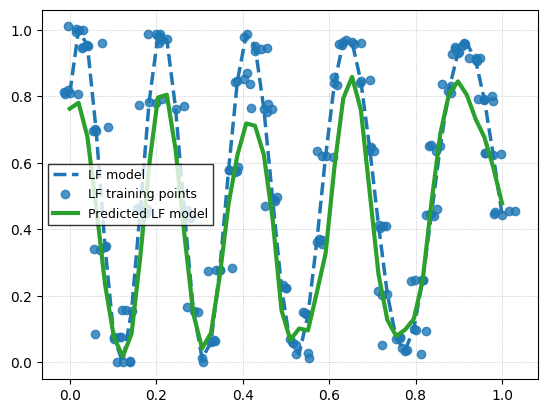

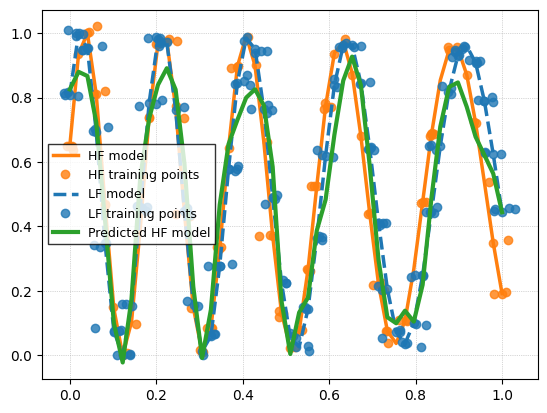

********************  # Nb. nodes = 28  ********************
********************  # Diff: = 0  ********************
********************  # NHF: = 100  ********************
********************  # NLF: = 200  ********************
The function training took 131.610376 seconds.


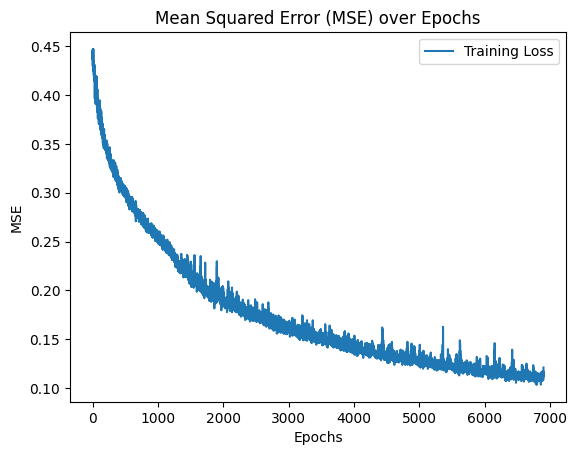

The function training took 144.174938 seconds.


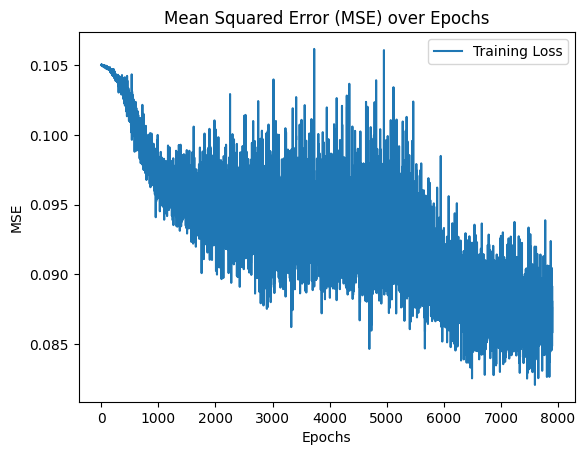

low fidelity NN
Test MSE: 0.049741922628281816
R^2: 0.600884597243834
Final model
Test MSE: 0.10627953020421028
R^2: 0.061124831586388706


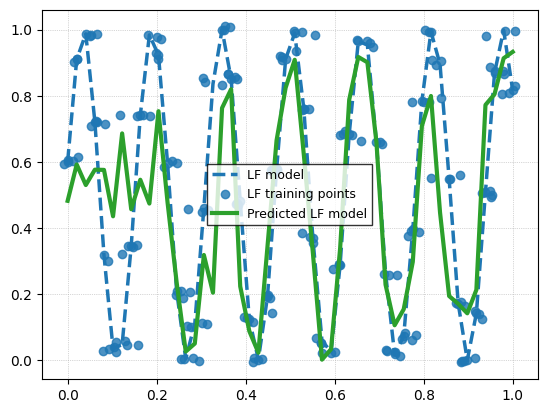

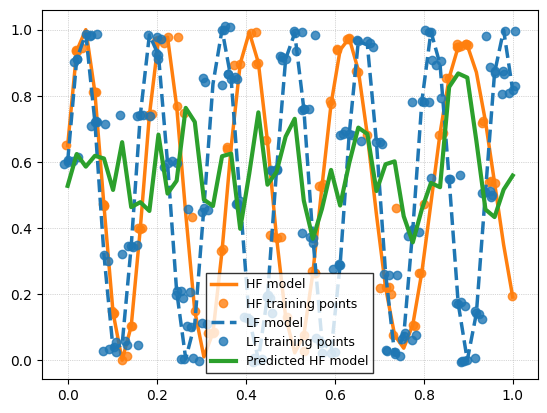

********************  # Nb. nodes = 28  ********************
********************  # Diff: = 5  ********************
********************  # NHF: = 100  ********************
********************  # NLF: = 200  ********************
The function training took 131.601148 seconds.


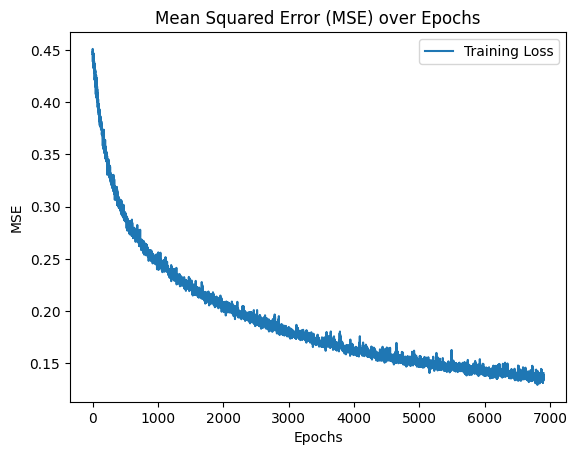

The function training took 143.413239 seconds.


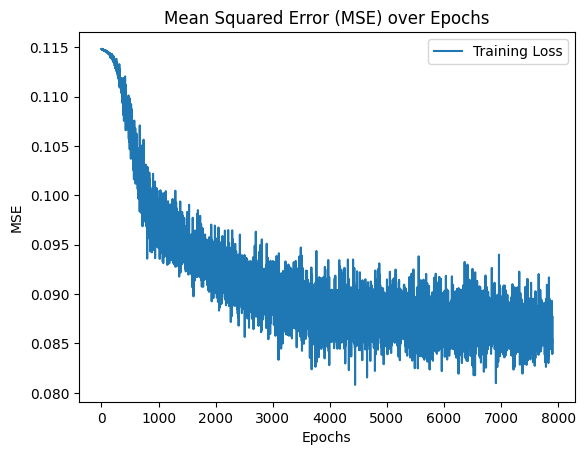

low fidelity NN
Test MSE: 0.08665881243320497
R^2: 0.23485120657955294
Final model
Test MSE: 0.09083016193334144
R^2: 0.19760481234397453


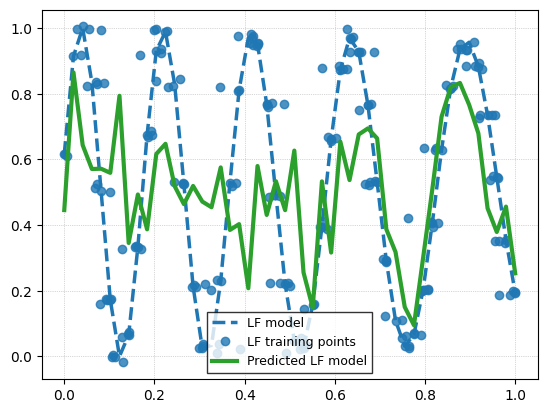

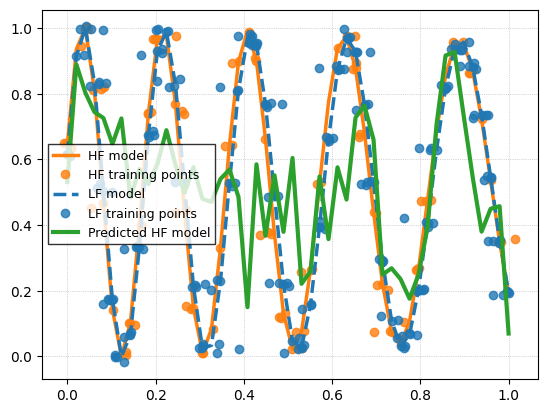

********************  # Nb. nodes = 28  ********************
********************  # Diff: = 75  ********************
********************  # NHF: = 100  ********************
********************  # NLF: = 200  ********************
The function training took 131.059491 seconds.


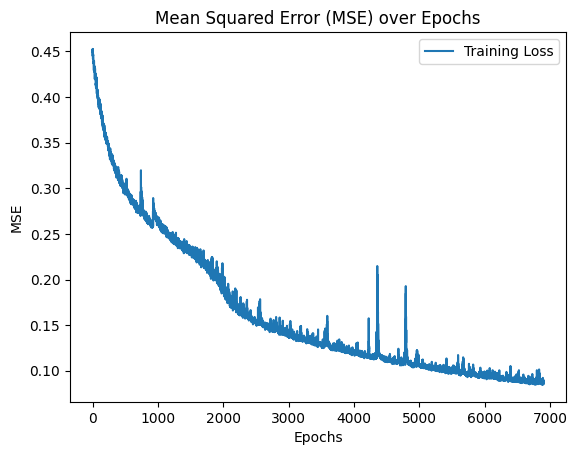

The function training took 143.121618 seconds.


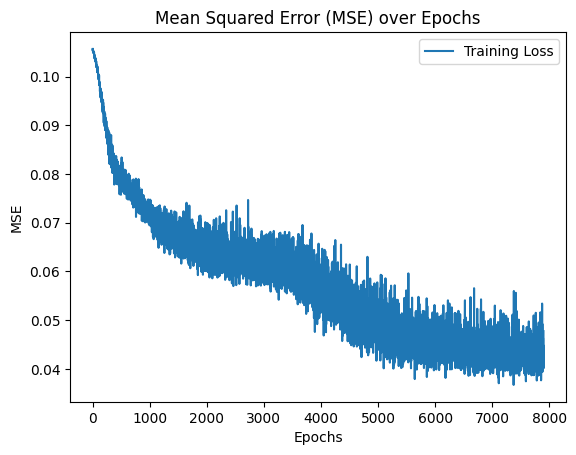

low fidelity NN
Test MSE: 0.005641201708085847
R^2: 0.9520210830591083
Final model
Test MSE: 0.033993124987603845
R^2: 0.6997041585870958


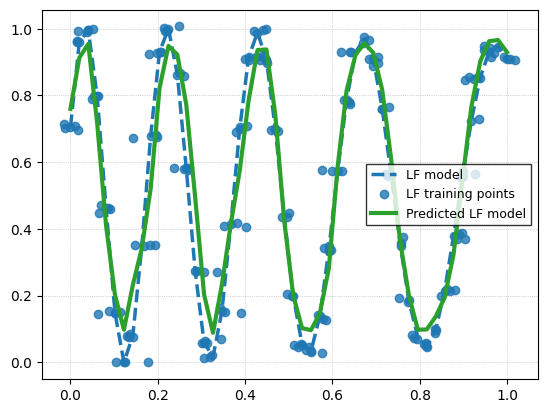

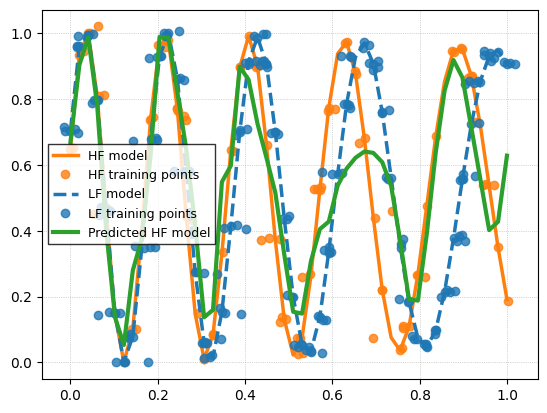

********************  # Nb. nodes = 28  ********************
********************  # Diff: = 1  ********************
********************  # NHF: = 100  ********************
********************  # NLF: = 200  ********************
The function training took 130.996887 seconds.


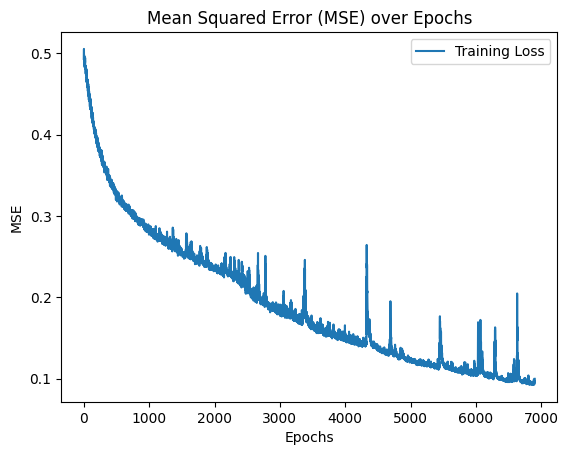

The function training took 143.361967 seconds.


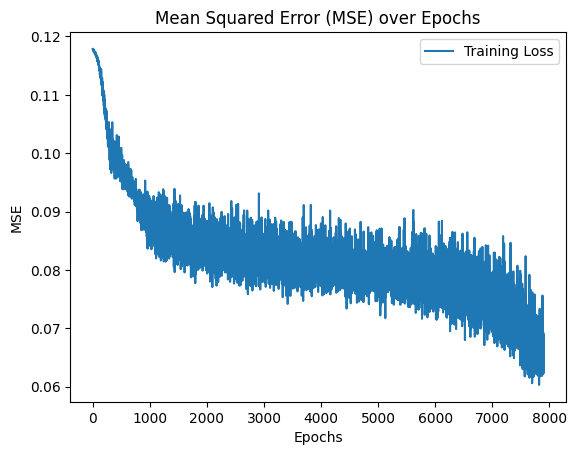

low fidelity NN
Test MSE: 0.011393316335465637
R^2: 0.9036474524744768
Final model
Test MSE: 0.04788946541868392
R^2: 0.5769436520484027


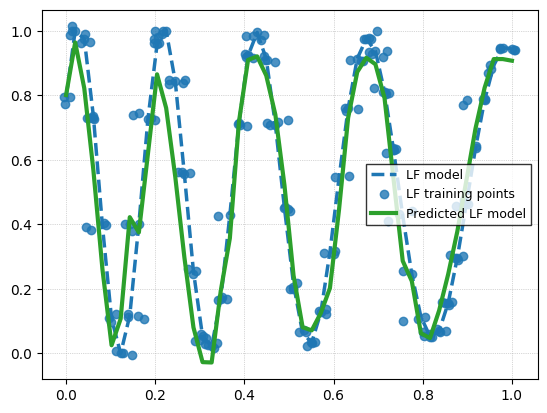

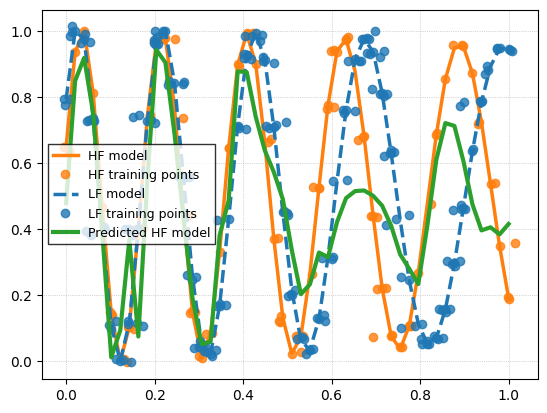

********************  # Nb. nodes = 10  ********************
********************  # Diff: = 0  ********************
********************  # NHF: = 100  ********************
********************  # NLF: = 200  ********************
The function training took 131.454533 seconds.


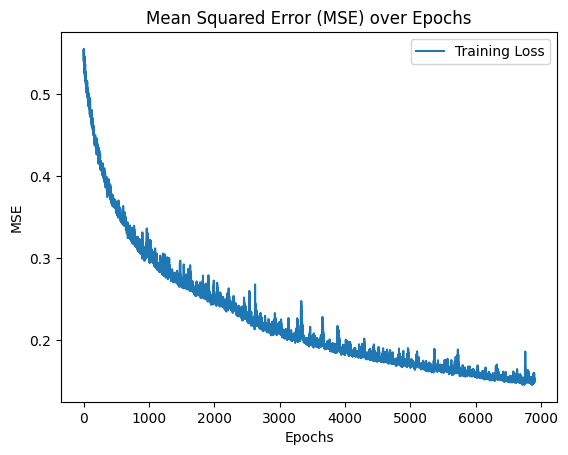

The function training took 142.815946 seconds.


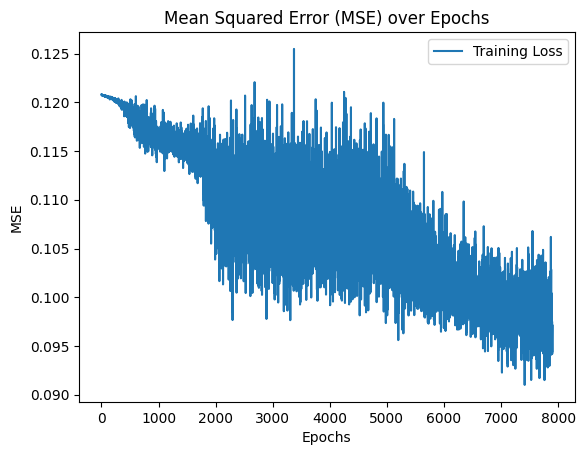

low fidelity NN
Test MSE: 0.020831879892911263
R^2: 0.8329052624704547
Final model
Test MSE: 0.08731918610313234
R^2: 0.22862083224498364


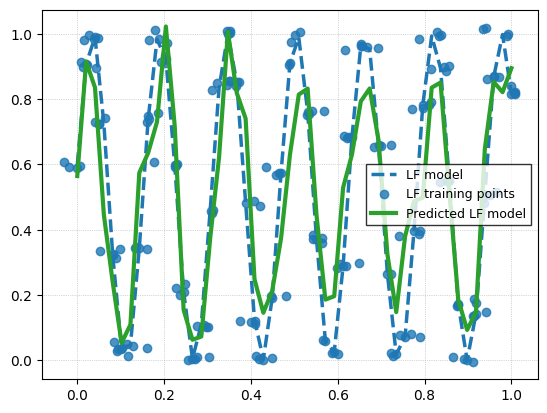

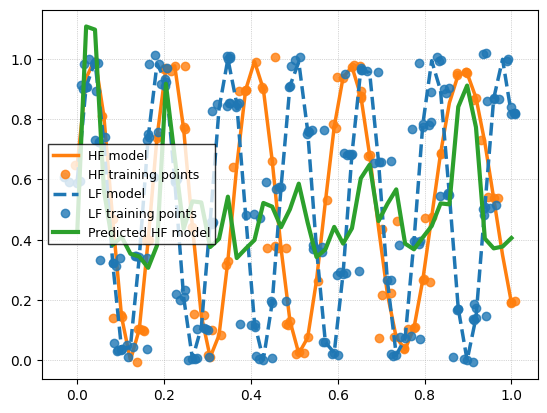

********************  # Nb. nodes = 10  ********************
********************  # Diff: = 5  ********************
********************  # NHF: = 100  ********************
********************  # NLF: = 200  ********************
The function training took 131.515663 seconds.


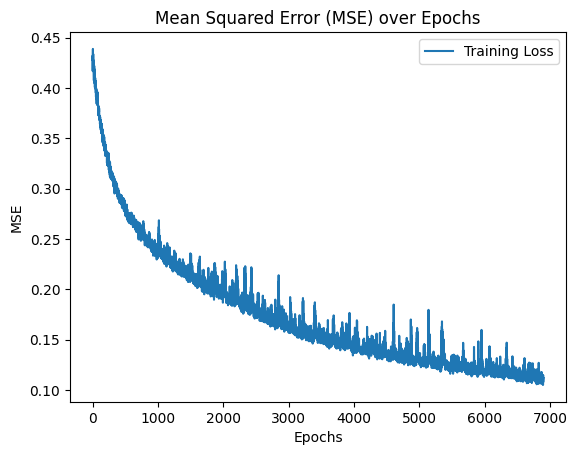

The function training took 142.424284 seconds.


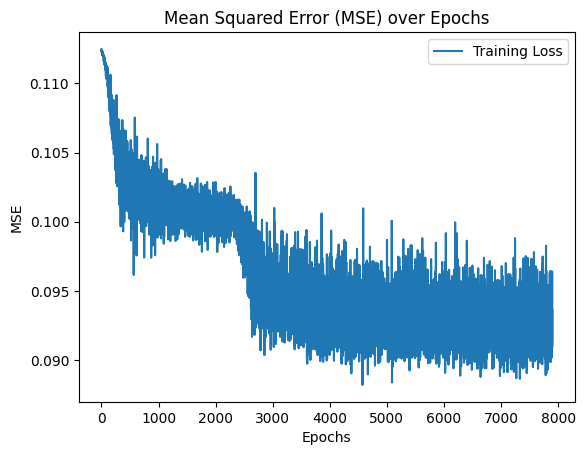

low fidelity NN
Test MSE: 0.026611735953288737
R^2: 0.7860991730137048
Final model
Test MSE: 0.09562527082949634
R^2: 0.15524473920676107


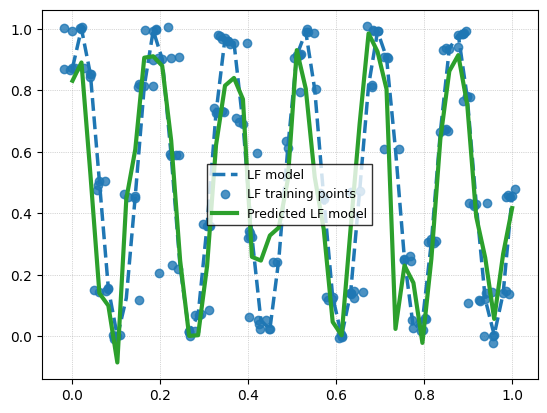

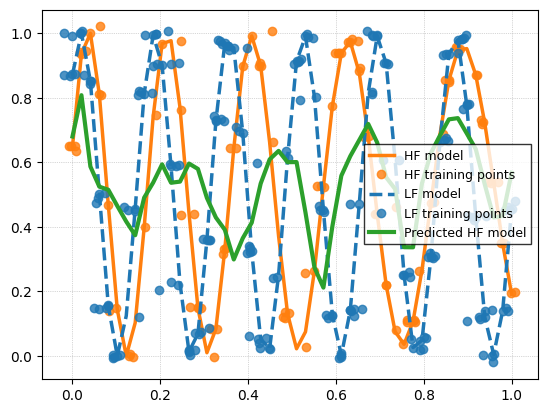

********************  # Nb. nodes = 10  ********************
********************  # Diff: = 75  ********************
********************  # NHF: = 100  ********************
********************  # NLF: = 200  ********************
The function training took 131.570661 seconds.


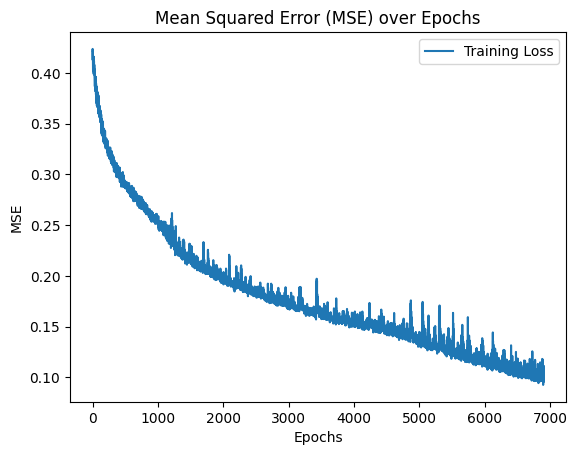

The function training took 143.675661 seconds.


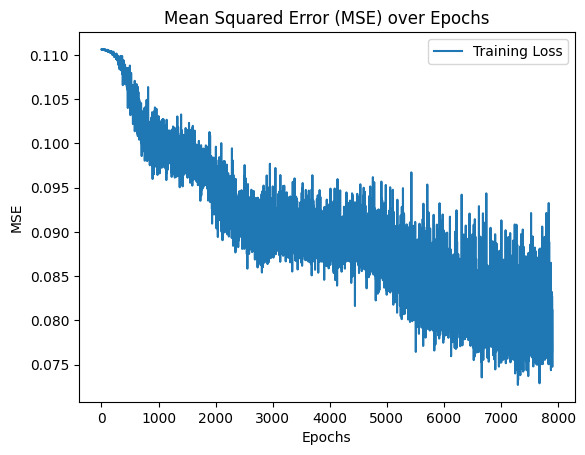

low fidelity NN
Test MSE: 0.019306710613952817
R^2: 0.8486623642717093
Final model
Test MSE: 0.07222238911328384
R^2: 0.3619861923394021


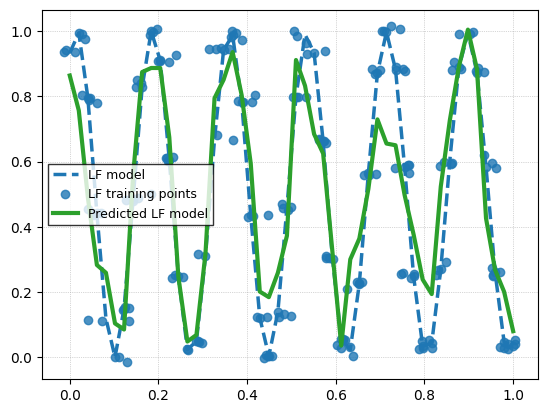

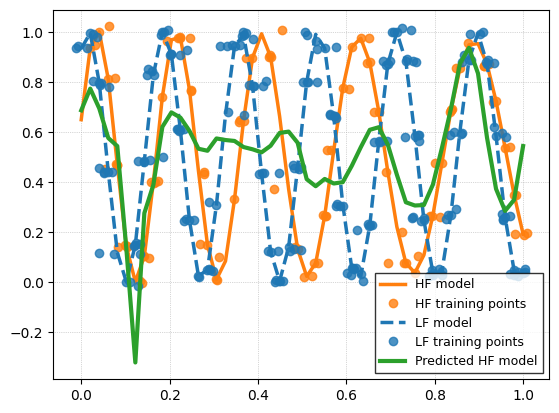

********************  # Nb. nodes = 10  ********************
********************  # Diff: = 1  ********************
********************  # NHF: = 100  ********************
********************  # NLF: = 200  ********************
The function training took 132.317177 seconds.


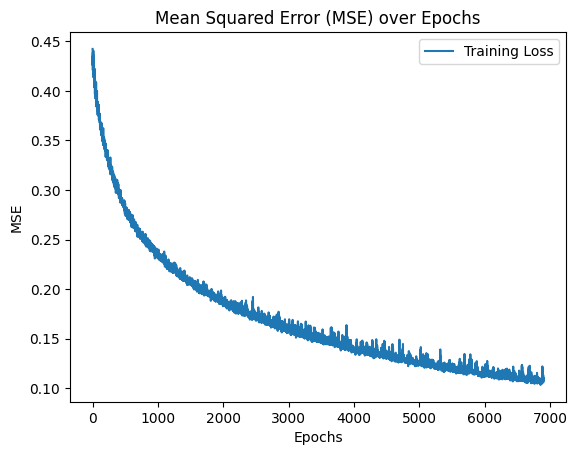

The function training took 142.495125 seconds.


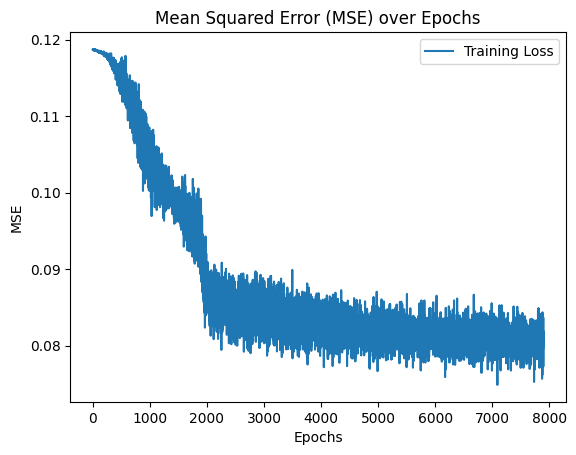

low fidelity NN
Test MSE: 0.028099025104225236
R^2: 0.7687197678248128
Final model
Test MSE: 0.07439442978561846
R^2: 0.34279834828212197


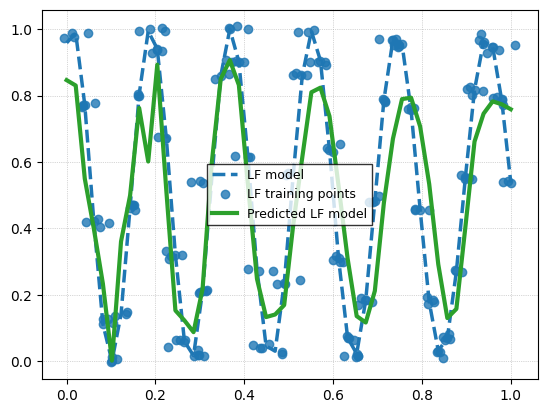

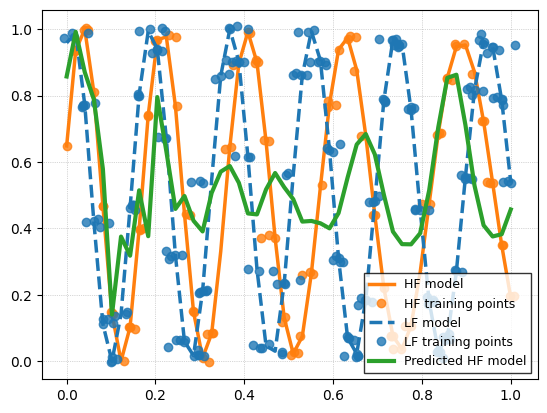

Empty DataFrame
Columns: [Discretization, diffusion, R2]
Index: []
Empty DataFrame
Columns: [Discretization, diffusion, MSE]
Index: []


In [9]:
# Name of the folder
folder_name = "2_step_models"
folder_path = os.path.join(os.getcwd(), folder_name)

# create the folder
if not os.path.exists(folder_path):
    os.makedirs(folder_path)
    print(f"Folder '{folder_name}' created.")
else:
    print(f"Folder '{folder_name}' already exists.")
               
for m in range(len(Discretizations)):
    test_mse_HF_list = []
    test_mse_LF_list = []

    r2_HF_list = []
    r2_LF_list = []

    for d in range(len(diffusion)):
        for nhf in n_HF:
            for nlf in Nlf:
        
                print(
                f"********************  # Nb. nodes = {Discretizations[m]}  ********************"
                )
                
                print(
                f"********************  # Diff: = {diffusion[d]}  ********************"
                )
                
                print(
                f"********************  # NHF: = {nhf}  ********************"
                )
                print(
                f"********************  # NLF: = {nlf}  ********************"
                )
                ### import of the Low Fidelity component of the dataset 
                file_path_LF = "../DATA_reaction/reaction_diffusion_LF_"+str(Discretizations[m])+"_d"+str(diffusion[d])+".mat"
                (reaction_LF_test, U_LF_test) = import_data(file_path_LF)

                # selection and normalization of the dataset
                U_LF_test = U_LF_test[:,- 1,int(4*(Discretizations[m]-1)/9),int(4*(Discretizations[m]-1)/9)] # indexes to find the same temporal (last) and spatial points        
                U_LF_test = normalization(U_LF_test)
                reaction_LF_test = normalization(reaction_LF_test)
                
                # transformation of the Low fidelity test set
                reaction_LF_test_original=np.c_[reaction_LF_test, np.abs(np.sin(5*np.pi*reaction_LF_test[:, 0]-5*np.pi/6))]
                U_LF_test_original=U_LF_test # keep the original for later evaluation and representation 
                
                # dataset augmentation adding a noise
                noise_std1=[0.02,0.01,0.02,0.01]
                noise_std2=[0.01,0.005,0.01,0.005]
                (U_LF_test,reaction_LF_test)=add_noise(noise_std1,noise_std2,reaction_LF_test,U_LF_test)
                
                # randomization and selection of the training set
                permutation = np.random.permutation(len(reaction_HF_test))
                reaction_HF = reaction_HF_test[permutation,:][0:nhf,:]
                U_HF = U_HF_test[permutation][0:nhf]
                permutation = np.random.permutation(len(reaction_LF_test))
                reaction_LF = reaction_LF_test[permutation][0:nlf]
                U_train_LF = U_LF_test[permutation][0:nlf]

                # transformation of the dataset
                reaction_LF=np.c_[reaction_LF, np.abs(np.sin(5*np.pi*reaction_LF[:, 0]-5*np.pi/6))]
                reaction_LF_test=np.c_[reaction_LF_test, np.abs(np.sin(5*np.pi*reaction_LF_test[:, 0]-5*np.pi/6))]
                
                ##########################      Neural Network     ##########################
                K.clear_session()
                
                # parameters 
                bestLF_params = {
                    "lr": 0.0255,
                    "kernel_init": "glorot_uniform",
                    "opt": "Adam",
                } 
                best_params={'kernel_init': 'uniform', 
                             'l2weight': 0.005395541657336886, 
                             'lr': 0.0025412188591473228, 
                             'nodes': 12.0, 
                             'opt': 'Adamax'}


                # Multifidelity network 
                names=["LF","HF"]
                params=[bestLF_params, best_params]
                data_train=[reaction_LF, reaction_HF]
                output_train=[U_train_LF,U_HF]

                definition_2steps = {
                                    "network_type": "2step",
                                    "names": names,
                                    "params": params,
                                    "data_train": data_train,
                                    "output_train": output_train,
                                    "N": Nepo,
                                    "n": batch_size,
                                    "train": True,
                                    "do_HPO": False,
                                    "verbose": False
                                    }
                model= NetworkFactory.build_network(**definition_2steps)
  

  
                ULF = model.model_list[0].prediction(reaction_LF_test_original)
                print("low fidelity NN")
                
                (test_mse_LF,r2_LF) = model.model_list[0].performance(reaction_LF_test_original,U_LF_test_original)
                test_mse_LF_list.append(test_mse_LF)
                r2_LF_list.append(r2_LF)

                input_HF = np.concatenate(
                    (reaction_HF_test_original,  model.model_list[0].prediction(reaction_HF_test_original).reshape(-1,1)),axis=1
                )  # <- TRAINING INPUT for the second NN: NN_HF

                input_HF_train = np.concatenate(
                    (reaction_HF,  model.model_list[0].prediction(reaction_HF).reshape(-1,1)),axis=1
                ) 
                print("Final model")
                (test_mse_HF,r2_HF) = model.model_list[1].performance(input_HF,U_HF_test_original)                
                test_mse_HF_list.append(test_mse_HF)
                r2_HF_list.append(r2_HF)
                
                
                # plots of the model

                plt.figure()

                plt.plot(reaction_LF_test_original[:, 0], U_LF_test_original, color="#1F77B4", linestyle="--", linewidth=2.5, label="LF model")

                plt.plot(
                    reaction_LF[:, 0],
                    U_train_LF,
                    "o",
                    markersize=6,
                    color="#1F77B4",
                    alpha=0.8,
                    label="LF training points",
                )

                plt.plot(
                    reaction_LF_test_original[:, 0],
                    model.model_list[0].prediction(reaction_LF_test_original),
                    color="#2CA02C",
                    linestyle="-",
                    linewidth=3,
                    label="Predicted LF model",
                )

                plt.legend(prop={"size": 9}, loc="best", frameon=True, fancybox=False, shadow=False, facecolor="white", edgecolor="black")
                plt.grid(True, which='both', linestyle=':', linewidth=0.5)

                plt.show()
                


                plt.figure()

                plt.plot(reaction_HF_test_original[:,0], U_HF_test_original, color="#FF7F0E", linestyle="-", linewidth=2.5, label="HF model")

                plt.plot(
                    input_HF_train[:, 0],
                    U_HF,
                    "o",
                    markersize=6,
                    color="#FF7F0E",
                    alpha=0.8,
                    label="HF training points",
                )

                plt.plot(reaction_LF_test_original[:, 0], U_LF_test_original, color="#1F77B4", linestyle="--", linewidth=2.5, label="LF model")

                plt.plot(
                    reaction_LF[:,0],
                    U_train_LF,
                    "o",
                    markersize=6,
                    color="#1F77B4",
                    alpha=0.8,
                    label="LF training points",
                )

                plt.plot(
                    input_HF[:, 0],
                    model.model_list[1].prediction(input_HF),
                    color="#2CA02C",
                    linestyle="-",
                    linewidth=3,
                    label="Predicted HF model",
                )

                plt.legend(prop={"size": 9}, loc="best", frameon=True, fancybox=False, shadow=False, facecolor="white", edgecolor="black")
                plt.grid(True, which='both', linestyle=':', linewidth=0.5)

                plt.show()
                
                # new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'R2': r2_LF_list[-1]}
                # r2_LF_df = pd.concat([r2_LF_df, pd.DataFrame([new])], ignore_index=True)

                # new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'R2': r2_HF_list[-1]}
                # r2_HF_df = pd.concat([r2_HF_df, pd.DataFrame([new])], ignore_index=True)

                # new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'MSE': test_mse_LF_list[-1]}
                # mse_LF_df = pd.concat([mse_LF_df, pd.DataFrame([new])], ignore_index=True)

                # new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'MSE': test_mse_HF_list[-1]}
                # mse_HF_df = pd.concat([mse_HF_df, pd.DataFrame([new])], ignore_index=True)
            
            
                # # save the model
                # if not r2_HF_list[:-1]:
                #     model.save(str(Discretizations[m]),folder_path)
                # elif r2_HF_list[:-1] and r2_HF_list[-1] < max(r2_HF_list[:-1]):
                #     model.save(str(Discretizations[m]),folder_path)

        
print(r2_HF_df.round(5))
print(mse_HF_df.round(5))